<a href="https://colab.research.google.com/github/husnakamilaa/smart_pyrolysis/blob/main/AI_TRAINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/02_final_all.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Index            751 non-null    int64  
 1   index            751 non-null    int64  
 2   Biomass species  751 non-null    object 
 3   M                751 non-null    float64
 4   Ash              751 non-null    float64
 5   VM               751 non-null    float64
 6   FC               751 non-null    float64
 7   C                751 non-null    float64
 8   H                751 non-null    float64
 9   O                751 non-null    float64
 10  N                751 non-null    float64
 11  FT               751 non-null    int64  
 12  HR               751 non-null    float64
 13  FR               751 non-null    float64
 14  Solid phase      751 non-null    float64
 15  Liquid phase     751 non-null    float64
 16  Gas phase        751 non-null    float64
 17  PS              

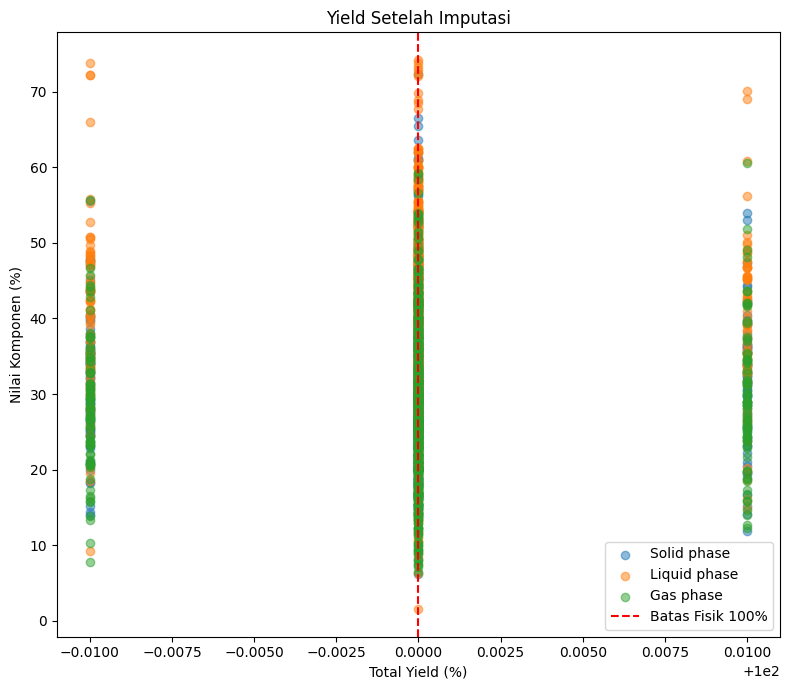

In [ ]:
import matplotlib.pyplot as plt

df['total_yield'] = df['Solid phase'] + df['Liquid phase'] + df['Gas phase']

plt.figure(figsize=(8, 7))
plt.scatter(df['total_yield'], df['Solid phase'], alpha=0.5, label='Solid phase')
plt.scatter(df['total_yield'], df['Liquid phase'], alpha=0.5, label='Liquid phase')
plt.scatter(df['total_yield'], df['Gas phase'], alpha=0.5, label='Gas phase')
plt.axvline(100, color='red', linestyle='--', label='Batas Fisik 100%')
plt.xlabel('Total Yield (%)')
plt.ylabel('Nilai Komponen (%)')
plt.title('Yield Setelah Imputasi')
plt.legend()
plt.tight_layout()
plt.savefig('yield_verification.png', dpi=150)

=== Statistik Total Yield ===
count    751.00
mean     100.00
std        0.00
min       99.99
25%      100.00
50%      100.00
75%      100.00
max      100.01
Name: total_yield, dtype: float64

=== Baris Anomali: 0 baris ===
Empty DataFrame
Columns: [Solid phase, Liquid phase, Gas phase, total_yield]
Index: []

Nilai negatif di 'Solid phase': 0 baris

Nilai negatif di 'Liquid phase': 0 baris

Nilai negatif di 'Gas phase': 0 baris

=== Missing Value Tersisa ===
Solid phase     0
Liquid phase    0
Gas phase       0
dtype: int64

Data bersih: 751 dari 751 baris


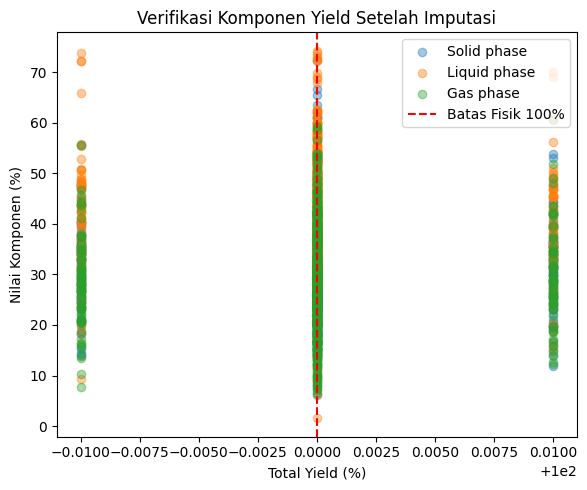

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Statistik total yield ───────────────────────────────
df['total_yield'] = df['Solid phase'] + df['Liquid phase'] + df['Gas phase']
print("=== Statistik Total Yield ===")
print(df['total_yield'].describe().round(2))

# ── 2. Baris anomali ──────────────────────────────────────
anomali = df[(df['total_yield'] < 90) | (df['total_yield'] > 110)]
print(f"\n=== Baris Anomali: {len(anomali)} baris ===")
print(anomali[['Solid phase', 'Liquid phase', 'Gas phase', 'total_yield']].head(20))

# ── 3. Cek nilai negatif ──────────────────────────────────
for col in ['Solid phase', 'Liquid phase', 'Gas phase']:
    neg = df[df[col] < 0]
    print(f"\nNilai negatif di '{col}': {len(neg)} baris")
    if len(neg) > 0:
        print(neg[['Solid phase', 'Liquid phase', 'Gas phase']].head(10))

# ── 4. Missing value tersisa ──────────────────────────────
print("\n=== Missing Value Tersisa ===")
print(df[['Solid phase', 'Liquid phase', 'Gas phase']].isnull().sum())

# ── 5. Plot hanya data bersih ─────────────────────────────
df_clean = df[(df['total_yield'] >= 90) & (df['total_yield'] <= 110)]
print(f"\nData bersih: {len(df_clean)} dari {len(df)} baris")

plt.figure(figsize=(6, 5))
plt.scatter(df_clean['total_yield'], df_clean['Solid phase'],  alpha=0.4, label='Solid phase')
plt.scatter(df_clean['total_yield'], df_clean['Liquid phase'], alpha=0.4, label='Liquid phase')
plt.scatter(df_clean['total_yield'], df_clean['Gas phase'],    alpha=0.4, label='Gas phase')
plt.axvline(100, color='red', linestyle='--', label='Batas Fisik 100%')
plt.xlabel('Total Yield (%)')
plt.ylabel('Nilai Komponen (%)')
plt.title('Verifikasi Komponen Yield Setelah Imputasi')
plt.legend()
plt.tight_layout()
plt.savefig('yield_verification_fixed.png', dpi=150)
plt.show()

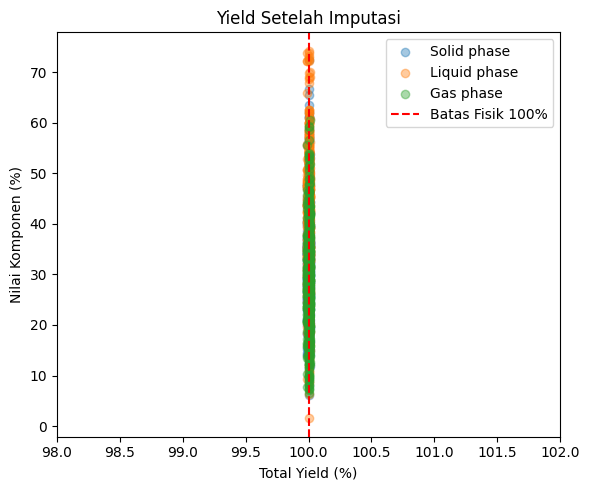

In [ ]:
import matplotlib.pyplot as plt

df['total_yield'] = df['Solid phase'] + df['Liquid phase'] + df['Gas phase']

plt.figure(figsize=(6, 5))
plt.scatter(df['total_yield'], df['Solid phase'],  alpha=0.4, label='Solid phase')
plt.scatter(df['total_yield'], df['Liquid phase'], alpha=0.4, label='Liquid phase')
plt.scatter(df['total_yield'], df['Gas phase'],    alpha=0.4, label='Gas phase')
plt.axvline(100, color='red', linestyle='--', label='Batas Fisik 100%')

# Fix: paksa sumbu X ke rentang yang relevan
plt.xlim(98, 102)

plt.xlabel('Total Yield (%)')
plt.ylabel('Nilai Komponen (%)')
plt.title('Yield Setelah Imputasi')
plt.legend()
plt.tight_layout()
plt.savefig('yield_verification_fixed.png', dpi=150)
plt.show()

In [ ]:
df

,Index,index,Biomass species,M,Ash,VM,FC,C,H,O,N,FT,HR,FR,Solid phase,Liquid phase,Gas phase,PS
0,1,0,Jerusalem artichoke stick,15.76,3.34,67.40,13.50,45.597105,6.141938,47.507037,0.753920,550,10.0,100.0,35.00,44.90,20.10,0.5
1,2,1,Jerusalem artichoke stick,15.76,3.34,67.40,13.50,45.597105,6.141938,47.507037,0.753920,650,10.0,100.0,31.75,41.25,27.00,0.5
2,3,2,Jerusalem artichoke stick,15.76,3.34,67.40,13.50,45.597105,6.141938,47.507037,0.753920,750,10.0,100.0,30.20,40.60,29.20,0.5
3,4,3,Jerusalem artichoke stick,15.76,3.34,67.40,13.50,45.597105,6.141938,47.507037,0.753920,850,10.0,100.0,28.60,36.36,35.04,0.5
4,5,4,reed,5.89,8.47,72.12,13.52,42.870027,5.180880,50.616294,1.332799,550,10.0,100.0,32.85,54.38,12.77,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,747,746,Karanja seed,7.27,1.50,89.23,2.00,53.130322,7.332465,35.590504,3.946709,500,20.0,40.0,25.56,49.84,24.61,0.5
747,748,747,Karanja seed,7.27,1.50,89.23,2.00,53.130322,7.332465,35.590504,3.946709,525,20.0,40.0,22.10,52.94,24.96,0.5
748,749,748,Karanja seed,7.27,1.50,89.23,2.00,53.130322,7.332465,35.590504,3.946709,550,20.0,40.0,19.98,54.68,25.34,0.5
749,750,749,Karanja seed,7.27,1.50,89.23,2.00,53.130322,7.332465,35.590504,3.946709,575,20.0,40.0,18.75,51.78,29.47,0.5


In [ ]:
df_train_1 = df.copy()

In [ ]:
df_train_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Index            751 non-null    int64  
 1   index            751 non-null    int64  
 2   Biomass species  751 non-null    object 
 3   M                751 non-null    float64
 4   Ash              751 non-null    float64
 5   VM               751 non-null    float64
 6   FC               751 non-null    float64
 7   C                751 non-null    float64
 8   H                751 non-null    float64
 9   O                751 non-null    float64
 10  N                751 non-null    float64
 11  FT               751 non-null    int64  
 12  HR               751 non-null    float64
 13  FR               751 non-null    float64
 14  Solid phase      751 non-null    float64
 15  Liquid phase     751 non-null    float64
 16  Gas phase        751 non-null    float64
 17  PS              

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_validate, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ====================================================================
# 1. PERSIAPAN DATASET (ISOLASI FITUR INPUT & TARGET YIELD)
# ====================================================================

# Saring fitur numerik input (Otomatis meninggalkan kolom Index, index, dan Biomass species)
fitur_X = ['M', 'Ash ', 'VM', 'FC', 'C', 'H', 'O', 'N', 'FT', 'HR', 'FR', 'PS']
X = df_train_1[fitur_X]

# Siapkan 3 target terpisah
target_yields = {
    'SOLID PHASE (Char)': df_train_1['Solid phase'],
    'LIQUID PHASE (Bio-oil)': df_train_1['Liquid phase'],
    'GAS PHASE': df_train_1['Gas phase']
}

# ====================================================================
# 2. KONFIGURASI ALGORITMA DAN STRATEGI VALIDASI
# ====================================================================

models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# ====================================================================
# 3. EKSEKUSI SPOT-CHECKING UNTUK SETIAP TARGET YIELD
# ====================================================================

print("====================================================================")
print("     FASE EVALUASI: SPOT-CHECKING MULTI-ALGORITMA PER TARGET YIELD  ")
print("====================================================================")

for nama_target, y in target_yields.items():
    print(f"\n🎯 TARGET EVALUASI: {nama_target}")
    print("=" * 60)

    for nama_model, model in models.items():
        # Menghitung metrik R2 dan MAE secara simultan via cross_validate
        skor = cross_validate(model, X, y, cv=kfold, scoring=['r2', 'neg_mean_absolute_error'])

        # PERBAIKAN DI SINI: Menggunakan string key resmi 'test_r2' dan 'test_neg_mean_absolute_error'
        r2_rata2 = np.mean(skor['test_r2'])
        mae_rata2 = np.mean(-skor['test_neg_mean_absolute_error']) # Ditambahkan awalan 'test_'

        print(f"🤖 Model: {nama_model:<15} | R² Score: {r2_rata2:.4f} | MAE Error: {mae_rata2:.4f} %")

    print("-" * 60)

     FASE EVALUASI: SPOT-CHECKING MULTI-ALGORITMA PER TARGET YIELD  

🎯 TARGET EVALUASI: SOLID PHASE (Char)
🤖 Model: Random Forest   | R² Score: 0.6604 | MAE Error: 3.1381 %
🤖 Model: XGBoost         | R² Score: 0.6997 | MAE Error: 2.8913 %
🤖 Model: LightGBM        | R² Score: 0.6706 | MAE Error: 3.1314 %
------------------------------------------------------------

🎯 TARGET EVALUASI: LIQUID PHASE (Bio-oil)
🤖 Model: Random Forest   | R² Score: 0.8077 | MAE Error: 3.2488 %
🤖 Model: XGBoost         | R² Score: 0.8060 | MAE Error: 3.1874 %
🤖 Model: LightGBM        | R² Score: 0.8054 | MAE Error: 3.4450 %
------------------------------------------------------------

🎯 TARGET EVALUASI: GAS PHASE
🤖 Model: Random Forest   | R² Score: 0.7484 | MAE Error: 3.2170 %
🤖 Model: XGBoost         | R² Score: 0.7705 | MAE Error: 3.1098 %
🤖 Model: LightGBM        | R² Score: 0.7512 | MAE Error: 3.2857 %
------------------------------------------------------------


#ANALISIS KORELASI

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Isolasi semua fitur numerik input (X)
fitur_X = ['M', 'Ash ', 'VM', 'FC', 'C', 'H', 'O', 'N', 'FT', 'HR', 'FR', 'PS']
X_vif = df_train_1[fitur_X].copy()

print("====================================================================")
print("     TAHAP 1: ANALISIS KORELASI PEARSON & DETEKSI MULTIKOLINEARITAS  ")
print("====================================================================")

# --- 1A. HITUNG MATRIKS KORELASI PEARSON ---
matriks_korelasi = X_vif.corr()

# Plot Heatmap Korelasi Pearson
# Catatan: Gunakan savefig() untuk menyimpan gambarnya
sns.set_theme(style='white')
mask = np.triu(np.ones_like(matriks_korelasi, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(matriks_korelasi, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .7}, annot=True, fmt=".2f", annot_kws={"size": 8})
plt.title("Pearson Correlation Matrix Antar Fitur Input", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('pearson_correlation_matrix.png', dpi=300)
plt.close()

print("✔ Gambar Heatmap Korelasi Pearson sukses disimpan dengan nama: 'pearson_correlation_matrix.png'")

# --- 1B. HITUNG VARIANCE INFLATION FACTOR (VIF) ---
vif_data = pd.DataFrame()
vif_data["Fitur Input"] = X_vif.columns
vif_data["Nilai VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\n=== TABEL DETEKSI MULTIKOLINEARITAS (VIF) ===")
print(vif_data.to_string(index=False))

     TAHAP 1: ANALISIS KORELASI PEARSON & DETEKSI MULTIKOLINEARITAS  
✔ Gambar Heatmap Korelasi Pearson sukses disimpan dengan nama: 'pearson_correlation_matrix.png'

=== TABEL DETEKSI MULTIKOLINEARITAS (VIF) ===
Fitur Input    Nilai VIF
          M 1.506232e+05
       Ash  4.148932e+05
         VM 8.322039e+05
         FC 3.640839e+05
          C 2.591999e+07
          H 4.761093e+05
          O 2.192365e+07
          N 8.732075e+04
         FT 1.054731e+00
         HR 1.099502e+00
         FR 1.091582e+00
         PS 1.030746e+00


#TRAIN - EVAL METRIC

## percobaan 1

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ====================================================================
# 1. SETUP SPLIT DATA (80% TRAIN, 20% TEST)
# ====================================================================
fitur_X = ['M', 'Ash ', 'VM', 'FC', 'C', 'H', 'O', 'N', 'FT', 'HR', 'FR', 'PS']
X = x_train[fitur_X]

# Mengunci target riil laboratorium (Hanya Solid dan Liquid)
y_train_solid = x_train['Solid phase']
y_train_liquid = x_train['Liquid phase']
y_train_gas = x_train['Gas phase'] # Hanya untuk pembanding evaluasi akhir

# Lakukan split 80:20 secara konsisten untuk kedua model
x_train, x_test, y_solid_train, y_solid_test = train_test_split(X, y_solid, test_size=0.2, random_state=42)
_, _, y_liquid_train, y_liquid_test = train_test_split(X, y_liquid, test_size=0.2, random_state=42)
_, _, _, y_gas_test_asli = train_test_split(X, y_gas_asli, test_size=0.2, random_state=42)

# Set strategi K-Fold CV untuk fase training di dalam data 80%
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# ====================================================================
# VERSI A: PROSES TRAINING DAN EVALUASI (TANPA TUNING)
# ====================================================================
print("\n" + "="*70)
print("      VERSI A: MODEL HIBRIDA LABORATORIUM (DEFAULT / TANPA TUNING)     ")
print("="*70)

# 1. Inisialisasi model default
rf_default = RandomForestRegressor(random_state=42)
xgb_default = XGBRegressor(random_state=42)

# 2. Latih menggunakan Cross Validation pada data Train (80%)
# cross_val_predict membantu merekam hasil tebakan tiap fold selama CV
cv_pred_solid_def = cross_val_predict(xgb_default, x_train, y_solid_train, cv=kfold)
cv_pred_liquid_def = cross_val_predict(rf_default, x_train, y_liquid_train, cv=kfold)

print(f"✔ [Fase CV Train 80%] R² Solid (XGBoost Default) : {r2_score(y_solid_train, cv_pred_solid_def):.4f}")
print(f"✔ [Fase CV Train 80%] R² Liquid (RF Default)     : {r2_score(y_liquid_train, cv_pred_liquid_def):.4f}")

# 3. Final Fit pada 80% untuk diuji ke data Test (20%)
xgb_default.fit(x_train, y_solid_train)
rf_default.fit(x_train, y_liquid_train)

# Tebak data Test 20%
test_pred_solid_def = xgb_default.predict(x_test)
test_pred_liquid_def = rf_default.predict(x_test)

# JEMBATAN LABORATORIUM (GAS BY DIFFERENCE)
test_pred_gas_def = 100.00 - (test_pred_solid_def + test_pred_liquid_def)

print("\n--- SKOR AKHIR EVALUASI PADA DATA TEST (20% DATA UNSEEN) ---")
print(f"🤖 SOLID (XGBoost Default)   -> R²: {r2_score(y_solid_test, test_pred_solid_def):.4f} | MAE: {mean_absolute_error(y_solid_test, test_pred_solid_def):.4f}%")
print(f"🤖 LIQUID (Random Forest Def)-> R²: {r2_score(y_liquid_test, test_pred_liquid_def):.4f} | MAE: {mean_absolute_error(y_liquid_test, test_pred_liquid_def):.4f}%")
print(f"🔬 GAS PHASE (By Difference) -> R²: {r2_score(y_gas_test_asli, test_pred_gas_def):.4f} | MAE: {mean_absolute_error(y_gas_test_asli, test_pred_gas_def):.4f}%")


# ====================================================================
# VERSI B: PROSES TRAINING DAN EVALUASI (DENGAN TUNING PARAMETER / HYPERPARAMETER TUNING)
# ====================================================================
print("\n" + "="*70)
print("     VERSI B: MODEL HIBRIDA LABORATORIUM (DENGAN GRIDSEARCH TUNING)    ")
print("="*70)

# 1. Tentukan ruang parameter (Grid) yang akan dicari kombinasinya
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1]
}

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

print("⏳ Sedang mencari setelan kompartemen reaktor terbaik lewat GridSearchCV...")

# 2. Jalankan Tuning otomatis di atas K-Fold CV data Train
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=kfold, scoring='r2', n_jobs=-1)
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=kfold, scoring='r2', n_jobs=-1)

grid_xgb.fit(x_train, y_solid_train)
grid_rf.fit(x_train, y_liquid_train)

print(f"✔ Setelan Terbaik Solid (XGBoost): {grid_xgb.best_params_}")
print(f"✔ Setelan Terbaik Liquid (RF)    : {grid_rf.best_params_}")

# 3. Ambil model jawara hasil tuning
xgb_tuned = grid_xgb.best_estimator_
rf_tuned = grid_rf.best_estimator_

# 4. Tebak data Test 20% menggunakan model hasil tuning
test_pred_solid_tuned = xgb_tuned.predict(x_test)
test_pred_liquid_tuned = rf_tuned.predict(x_test)

# JEMBATAN LABORATORIUM (GAS BY DIFFERENCE KEDUA)
test_pred_gas_tuned = 100.00 - (test_pred_solid_tuned + test_pred_liquid_tuned)

print("\n--- SKOR AKHIR EVALUASI PASCA TUNING PADA DATA TEST (20% DATA UNSEEN) ---")
print(f"🚀 SOLID (XGBoost Tuned)   -> R²: {r2_score(y_solid_test, test_pred_solid_tuned):.4f} | MAE: {mean_absolute_error(y_solid_test, test_pred_solid_tuned):.4f}%")
print(f"🚀 LIQUID (Random Forest Tuned)-> R²: {r2_score(y_liquid_test, test_pred_liquid_tuned):.4f} | MAE: {mean_absolute_error(y_liquid_test, test_pred_liquid_tuned):.4f}%")
print(f"🔬 GAS PHASE (By Difference)   -> R²: {r2_score(y_gas_test_asli, test_pred_gas_tuned):.4f} | MAE: {mean_absolute_error(y_gas_test_asli, test_pred_gas_tuned):.4f}%")

KeyError: 'Solid phase'

## percobaan 2

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ====================================================================
# 1. DUPLIKASI DATASET UTAMA KE df_train_2
# ====================================================================
# Membuat salinan independen agar tidak mencemari df_train_1
df_train_2 = df.copy()

# Isolasi fitur input dan target yields
fitur_X = ['M', 'Ash ', 'VM', 'FC', 'C', 'H', 'O', 'N', 'FT', 'HR', 'FR', 'PS']
X = df_train_2[fitur_X]

y_solid = df_train_2['Solid phase']
y_liquid = df_train_2['Liquid phase']
y_gas_asli = df_train_2['Gas phase'] # Digunakan murni sebagai pembanding evaluasi akhir

# ====================================================================
# 2. SETUP DATA SPLIT (80% TRAIN, 20% TEST) & STRATEGI CV
# ====================================================================
X_train, X_test, y_solid_train, y_solid_test = train_test_split(X, y_solid, test_size=0.2, random_state=42)
_, _, y_liquid_train, y_liquid_test = train_test_split(X, y_liquid, test_size=0.2, random_state=42)
_, _, _, y_gas_test_asli = train_test_split(X, y_gas_asli, test_size=0.2, random_state=42)

# Menggunakan 5-Fold Cross Validation untuk dipasangkan ke GridSearchCV
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("====================================================================")
print("     FASE TUNING SKALA PENH (FULL-SCALE TUNING) PADA df_train_2      ")
print("====================================================================")
print("⏳ Komputer sedang menyisir kombinasi parameter baru yang lebih luas...")

# ====================================================================
# 3. PENYUSUNAN RUANG PARAMETER YANG LEBIH LUAS (EXPANDED GRID)
# ====================================================================
# Menambahkan parameter regularisasi dan kontrol kedalaman agar anti-overfitting
param_grid_xgb_luas = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],               # Mencegah overfitting lokal data train
    'colsample_bytree': [0.8, 1.0]         # Membatasi tumpang tindih fitur saat memotong pohon
}

# Menambahkan pembatasan ukuran daun pada struktur Random Forest
param_grid_rf_luas = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]             # Membantu meredam noise ekstrem dari data laboratorium
}

# ====================================================================
# 4. EKSEKUSI GRIDSEARCHCV SKALA PENUH
# ====================================================================
grid_xgb_2 = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb_luas, cv=kfold, scoring='r2', n_jobs=-1)
grid_rf_2 = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf_luas, cv=kfold, scoring='r2', n_jobs=-1)

# Latih model mencari titik kombinasi paling harmonis
grid_xgb_2.fit(X_train, y_solid_train)
grid_rf_2.fit(X_train, y_liquid_train)

print("\n✔ Pencarian selesai!")
print(f"📌 Kombinasi Parameter Terbaik Solid (XGBoost) : {grid_xgb_2.best_params_}")
print(f"📌 Kombinasi Parameter Terbaik Liquid (RF)     : {grid_rf_2.best_params_}")

# ====================================================================
# 5. EVALUASI AKHIR MODEL OPTIMAL DI DATA TEST (20% DATA UNSEEN)
# ====================================================================
# Ambil arsitektur terbaik hasil optimasi skala luas
xgb_final_model = grid_xgb_2.best_estimator_
rf_final_model = grid_rf_2.best_estimator_

# Prediksi 20% data test rahasia
test_pred_solid_final = xgb_final_model.predict(X_test)
test_pred_liquid_final = rf_final_model.predict(X_test)

# JEMBATAN LABORATORIUM (GAS BY DIFFERENCE MUTLAK)
test_pred_gas_final = 100.00 - (test_pred_solid_final + test_pred_liquid_final)

print("\n" + "="*70)
print("     LAPORAN PERFORMA AKHIR MODEL REAKTOR VIRTUAL (DATA TEST 20%)     ")
print("="*70)
print(f"🚀 SOLID PHASE (XGBoost Optimal)   -> R²: {r2_score(y_solid_test, test_pred_solid_final):.4f} | MAE: {mean_absolute_error(y_solid_test, test_pred_solid_final):.4f}%")
print(f"🚀 LIQUID PHASE (Random Forest Opt)-> R²: {r2_score(y_liquid_test, test_pred_liquid_final):.4f} | MAE: {mean_absolute_error(y_liquid_test, test_pred_liquid_final):.4f}%")
print(f"🔬 GAS PHASE (By Difference Final) -> R²: {r2_score(y_gas_test_asli, test_pred_gas_final):.4f} | MAE: {mean_absolute_error(y_gas_test_asli, test_pred_gas_final):.4f}%")
print("="*70)

     FASE TUNING SKALA PENH (FULL-SCALE TUNING) PADA df_train_2      
⏳ Komputer sedang menyisir kombinasi parameter baru yang lebih luas...

✔ Pencarian selesai!
📌 Kombinasi Parameter Terbaik Solid (XGBoost) : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
📌 Kombinasi Parameter Terbaik Liquid (RF)     : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

     LAPORAN PERFORMA AKHIR MODEL REAKTOR VIRTUAL (DATA TEST 20%)     
🚀 SOLID PHASE (XGBoost Optimal)   -> R²: 0.7608 | MAE: 2.6711%
🚀 LIQUID PHASE (Random Forest Opt)-> R²: 0.7630 | MAE: 3.2677%
🔬 GAS PHASE (By Difference Final) -> R²: 0.7864 | MAE: 3.0310%


## percobaan 3

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ====================================================================
# 1. DUPLIKASI DATASET KE df_train_3 (GARANSI ANTI BOCOR & BERSIH)
# ====================================================================
df_train_3 = df.copy()

# Isolasi Fitur dan Target
fitur_X = ['M', 'Ash ', 'VM', 'FC', 'C', 'H', 'O', 'N', 'FT', 'HR', 'FR', 'PS']
X = df_train_3[fitur_X]

y_solid = df_train_3['Solid phase']
y_liquid = df_train_3['Liquid phase']
y_gas_asli = df_train_3['Gas phase']

# Split 80:20 secara konsisten mengunci random state
X_train, X_test, y_solid_train, y_solid_test = train_test_split(X, y_solid, test_size=0.2, random_state=42)
_, _, y_liquid_train, y_liquid_test = train_test_split(X, y_liquid, test_size=0.2, random_state=42)
_, _, _, y_gas_test_asli = train_test_split(X, y_gas_asli, test_size=0.2, random_state=42)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("====================================================================")
# Pencarian parameter skala makro-mikro untuk mengunci kestabilan fisis
print("   FASE TUNING ULTRA PRESIZI (ADVANCED HYPERTUNING) PADA df_train_3  ")
print("====================================================================")
print("⏳ Menjelajahi kombinasi regularisasi fisis (Proses memakan waktu)...")

# ====================================================================
# 2. STRATEGI GRID PARAMETER TINGKAT LANJUT (ANTI-OVERFITTING)
# ====================================================================

# Untuk XGBoost Solid: Fokus pada kontrol kecepatan belajar mikro & penalti regularisasi (alpha/lambda)
param_grid_xgb_ultra = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.07], # Rentang mikro di sekitar 0.05 (jawara df_train_2)
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5],          # Regularisasi L1 untuk memangkas fitur tidak berguna
    'reg_lambda': [1, 1.5, 2]            # Regularisasi L2 untuk menghaluskan bobot prediksi
}

# Untuk Random Forest Liquid: Fokus pada variasi fitur percabangan & ukuran daun minimal
param_grid_rf_ultra = {
    'n_estimators': [200, 300, 400],     # Memperbanyak jumlah pohon agar voting lebih stabil
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None] # Mengacak subset fitur agar tangguh menghadapi multikolinearitas VIF
}

# ====================================================================
# 3. EKSEKUSI GRIDSEARCHCV ULTRA
# ====================================================================
grid_xgb_3 = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb_ultra, cv=kfold, scoring='r2', n_jobs=-1)
grid_rf_3 = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf_ultra, cv=kfold, scoring='r2', n_jobs=-1)

grid_xgb_3.fit(X_train, y_solid_train)
grid_rf_3.fit(X_train, y_liquid_train)

print("\n✔ Perburuan Parameter Selesai!")
print(f"📌 Setelan Jinak Terbaik Solid (XGBoost) : {grid_xgb_3.best_params_}")
print(f"📌 Setelan Jinak Terbaik Liquid (RF)     : {grid_rf_3.best_params_}")

# ====================================================================
# 4. EVALUASI AKHIR PADA DATA UJIAN (DATA TEST 20%)
# ====================================================================
xgb_ultra_model = grid_xgb_3.best_estimator_
rf_ultra_model = grid_rf_3.best_estimator_

test_pred_solid_ultra = xgb_ultra_model.predict(X_test)
test_pred_liquid_ultra = rf_ultra_model.predict(X_test)

# JEMBATAN LABORATORIUM (GAS BY DIFFERENCE AMAN MUTLAK)
test_pred_gas_ultra = 100.00 - (test_pred_solid_ultra + test_pred_liquid_ultra)

print("\n" + "="*70)
print("     LAPORAN PERFORMA ULTRA MODEL REAKTOR VIRTUAL (df_train_3)     ")
print("="*70)
print(f"🚀 SOLID PHASE (XGBoost Ultra)   -> R²: {r2_score(y_solid_test, test_pred_solid_ultra):.4f} | MAE: {mean_absolute_error(y_solid_test, test_pred_solid_ultra):.4f}%")
print(f"🚀 LIQUID PHASE (Random Forest Ult)-> R²: {r2_score(y_liquid_test, test_pred_liquid_ultra):.4f} | MAE: {mean_absolute_error(y_liquid_test, test_pred_liquid_ultra):.4f}%")
print(f"🔬 GAS PHASE (By Difference Ultra) -> R²: {r2_score(y_gas_test_asli, test_pred_gas_ultra):.4f} | MAE: {mean_absolute_error(y_gas_test_asli, test_pred_gas_ultra):.4f}%")
print("="*70)

   FASE TUNING ULTRA PRESIZI (ADVANCED HYPERTUNING) PADA df_train_3  
⏳ Menjelajahi kombinasi regularisasi fisis (Proses memakan waktu)...

✔ Perburuan Parameter Selesai!
📌 Setelan Jinak Terbaik Solid (XGBoost) : {'colsample_bytree': 0.7, 'learning_rate': 0.07, 'max_depth': 4, 'n_estimators': 400, 'reg_alpha': 0, 'reg_lambda': 2, 'subsample': 0.8}
📌 Setelan Jinak Terbaik Liquid (RF)     : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

     LAPORAN PERFORMA ULTRA MODEL REAKTOR VIRTUAL (df_train_3)     
🚀 SOLID PHASE (XGBoost Ultra)   -> R²: 0.7648 | MAE: 2.6616%
🚀 LIQUID PHASE (Random Forest Ult)-> R²: 0.7633 | MAE: 3.3860%
🔬 GAS PHASE (By Difference Ultra) -> R²: 0.7882 | MAE: 3.0745%


# INTERPRETASI

## percobaan 3

     PROSES GENERATE GRAFIK SHAP INTERPRETASI OPTIMAL (df_train_3)   

🔮 Mengalkulasi SHAP untuk SOLID PHASE (XGBoost)...


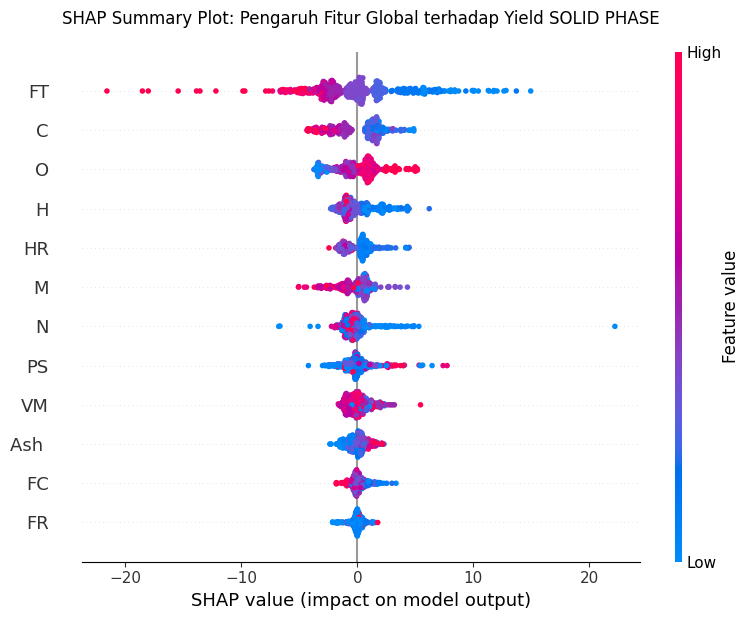

✔ Grafik 'shap_solid_summary.png' sukses disimpan.


<Figure size 800x500 with 0 Axes>

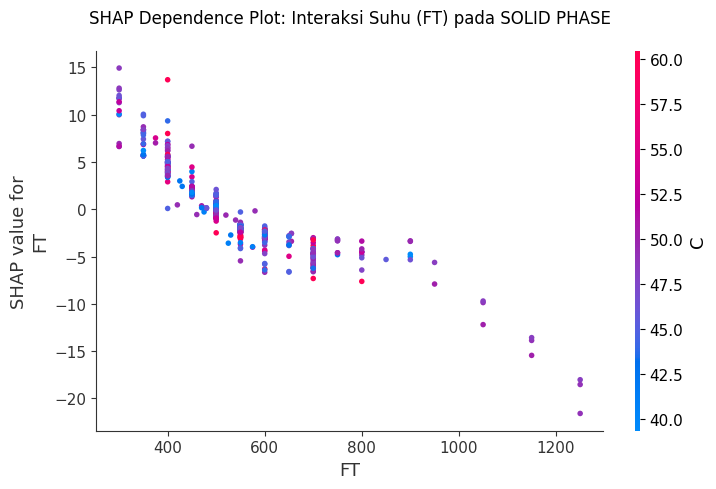

✔ Grafik 'shap_solid_dependence_ft.png' sukses disimpan.

🔮 Mengalkulasi SHAP untuk LIQUID PHASE (Random Forest)...


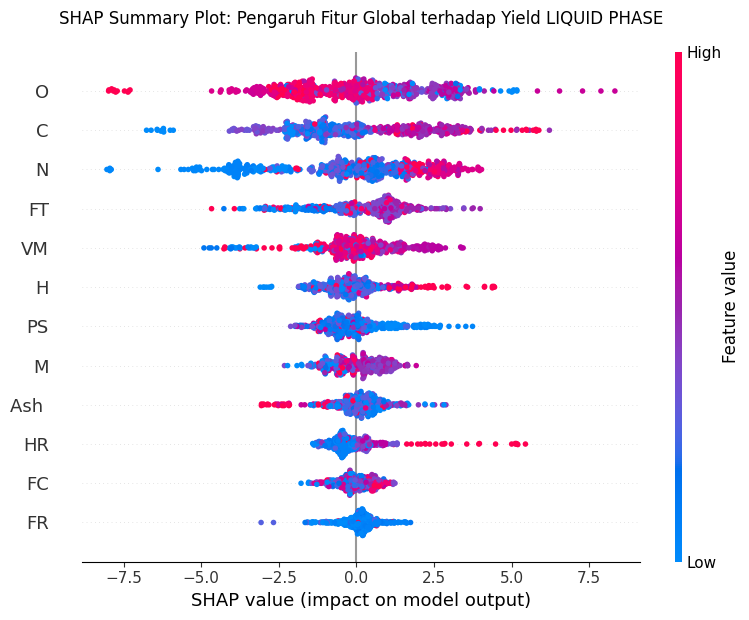

✔ Grafik 'shap_liquid_summary.png' sukses disimpan.


<Figure size 800x500 with 0 Axes>

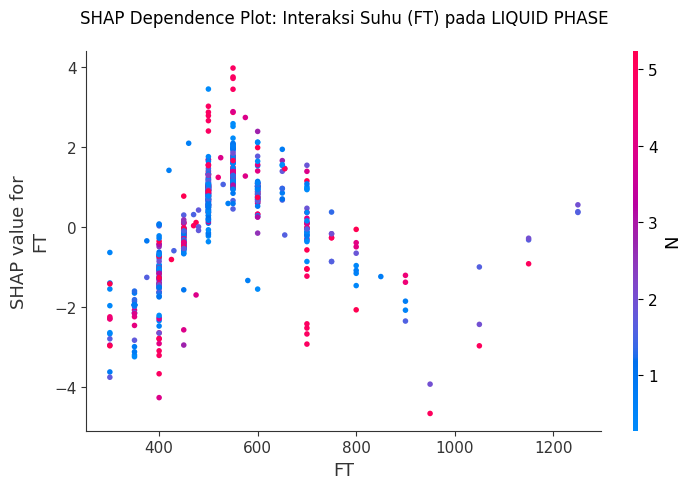

✔ Grafik 'shap_liquid_dependence_ft.png' sukses disimpan.

🎉 SEMUA GRAFIK INTERPRETASI BERHASIL DISESUAIKAN DAN DISIMPAN!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Menyiapkan Data Berdasarkan df_train_3 (Konsisten 80% Train untuk SHAP)
fitur_X = ['M', 'Ash ', 'VM', 'FC', 'C', 'H', 'O', 'N', 'FT', 'HR', 'FR', 'PS']
X = df_train_3[fitur_X]

y_solid = df_train_3['Solid phase']
y_liquid = df_train_3['Liquid phase']

from sklearn.model_selection import train_test_split
X_train, X_test, y_solid_train, y_solid_test = train_test_split(X, y_solid, test_size=0.2, random_state=42)
_, _, y_liquid_train, _ = train_test_split(X, y_liquid, test_size=0.2, random_state=42)

print("====================================================================")
print("     PROSES GENERATE GRAFIK SHAP INTERPRETASI OPTIMAL (df_train_3)   ")
print("====================================================================")

# ====================================================================
# FASA 1: VISUALISASI UNTUK SOLID PHASE (XGBOOST ULTRA)
# ====================================================================
print("\n🔮 Mengalkulasi SHAP untuk SOLID PHASE (XGBoost)...")
model_solid_final = XGBRegressor(
    colsample_bytree=0.7, learning_rate=0.07, max_depth=4,
    n_estimators=400, reg_alpha=0, reg_lambda=2, subsample=0.8, random_state=42
)
model_solid_final.fit(X_train, y_solid_train)

explainer_solid = shap.TreeExplainer(model_solid_final)
shap_values_solid = explainer_solid(X_train)

# Grafik 1: Summary Plot Solid
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_solid, X_train, show=False)
plt.title("SHAP Summary Plot: Pengaruh Fitur Global terhadap Yield SOLID PHASE", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('shap_solid_summary.png', dpi=300)
plt.show()
print("✔ Grafik 'shap_solid_summary.png' sukses disimpan.")

# Grafik 2: Dependence Plot Solid (Interaksi Suhu FT dengan komponen kimia)
plt.figure(figsize=(8, 5))
# SHAP otomatis mencarikan fitur interaksi paling kuat dengan FT jika interaction_index='auto'
shap.dependence_plot("FT", shap_values_solid.values, X_train, show=False)
plt.title("SHAP Dependence Plot: Interaksi Suhu (FT) pada SOLID PHASE", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('shap_solid_dependence_ft.png', dpi=300)
plt.show()
print("✔ Grafik 'shap_solid_dependence_ft.png' sukses disimpan.")


# ====================================================================
# FASA 2: VISUALISASI UNTUK LIQUID PHASE (RANDOM FOREST ULTRA)
# ====================================================================
print("\n🔮 Mengalkulasi SHAP untuk LIQUID PHASE (Random Forest)...")
model_liquid_final = RandomForestRegressor(
    max_depth=20, max_features='sqrt', min_samples_leaf=1,
    min_samples_split=2, n_estimators=300, random_state=42
)
model_liquid_final.fit(X_train, y_liquid_train)

explainer_liquid = shap.TreeExplainer(model_liquid_final)
shap_values_liquid = explainer_liquid(X_train)

# Grafik 3: Summary Plot Liquid
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_liquid, X_train, show=False)
plt.title("SHAP Summary Plot: Pengaruh Fitur Global terhadap Yield LIQUID PHASE", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('shap_liquid_summary.png', dpi=300)
plt.show()
print("✔ Grafik 'shap_liquid_summary.png' sukses disimpan.")

# Grafik 4: Dependence Plot Liquid (Interaksi Suhu FT pada pembentukan Bio-oil)
plt.figure(figsize=(8, 5))
shap.dependence_plot("FT", shap_values_liquid.values, X_train, show=False)
plt.title("SHAP Dependence Plot: Interaksi Suhu (FT) pada LIQUID PHASE", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('shap_liquid_dependence_ft.png', dpi=300)
plt.show()
print("✔ Grafik 'shap_liquid_dependence_ft.png' sukses disimpan.")

print("\n🎉 SEMUA GRAFIK INTERPRETASI BERHASIL DISESUAIKAN DAN DISIMPAN!")

In [ ]:
import pandas as pd

# Pastikan menggunakan data aktif df_train_3
df_analisis = df_train_3.copy()

# Jika di datasetmu ada kolom nama sampel/spesies biomassa (misal kolom 'Spesies' atau 'Nama'),
# pastikan kolom itu ikut terbawa untuk di-print.
# Di sini saya asumsikan ada kolom pembeda atau kita tampilkan indeks barisnya.

print("====================================================================")
print("   SISTEM FILTER REKOMENDASI SPESIES BIOMASSA TERBAIK (df_train_3)   ")
print("====================================================================")

# ====================================================================
# FASA 1: REKOMENDASI SPESIES UNTUK PRODUKSI SOLID (CHAR) MAKSIMAL
# ====================================================================
print("\n🪵 [SOLID PHASE] Menyeleksi Spesies Ideal untuk Kuantitas Arang Tinggi...")
print("Kriteria: Mengutamakan Fixed Carbon (FC) Tinggi pada Suhu Operasi Rendah (FT <= 400°C)")

# Filter data yang berjalan di suhu rendah, lalu urutkan berdasarkan FC tertinggi
rekomendasi_solid = df_analisis[df_analisis['FT'] <= 400].sort_values(by='FC', ascending=False)

# Mengambil 5 sampel spesies terbaik
top_5_solid = rekomendasi_solid[['FC', 'VM', 'FT', 'Solid phase']].head(5)
print("\nTop 5 Baris Data Sampel Terbaik untuk Solid Yield:")
print(top_5_solid.to_string(index=True))


print("\n" + "-"*70)


# ====================================================================
# FASA 2: REKOMENDASI SPESIES UNTUK PRODUKSI LIQUID (BIO-OIL) MAKSIMAL
# ====================================================================
print("\n🧪 [LIQUID PHASE] Menyeleksi Spesies Ideal untuk Kuantitas Bio-oil Tinggi...")
print("Kriteria: Mengutamakan Oksigen (O) Rendah, Volatile Matter (VM) Tinggi, pada Suhu Optimal (450°C - 550°C)")

# 1. Filter reaktor pada zona suhu bukit optimal (450 - 550°C)
zona_optimal_liquid = df_analisis[(df_analisis['FT'] >= 450) & (df_analisis['FT'] <= 550)].copy()

# 2. Membuat skor pembobotan kimia murni berdasarkan SHAP:
# Karena Oksigen merusak (berbanding terbalik), kita beri tanda minus (- O).
# Karena VM mendorong (berbanding lurus), kita beri tanda plus (+ VM).
zona_optimal_liquid['Skor_Kimia_Minyak'] = zona_optimal_liquid['VM'] - zona_optimal_liquid['O']

# 3. Urutkan berdasarkan skor kombinasi terbaik tersebut
rekomendasi_liquid = zona_optimal_liquid.sort_values(by='Skor_Kimia_Minyak', ascending=False)

# Mengambil 5 sampel spesies terbaik
top_5_liquid = rekomendasi_liquid[['O', 'VM', 'FT', 'Liquid phase', 'Skor_Kimia_Minyak']].head(5)
print("\nTop 5 Baris Data Sampel Terbaik untuk Liquid Yield:")
print(top_5_liquid.to_string(index=True))

   SISTEM FILTER REKOMENDASI SPESIES BIOMASSA TERBAIK (df_train_3)   

🪵 [SOLID PHASE] Menyeleksi Spesies Ideal untuk Kuantitas Arang Tinggi...
Kriteria: Mengutamakan Fixed Carbon (FC) Tinggi pada Suhu Operasi Rendah (FT <= 400°C)

Top 5 Baris Data Sampel Terbaik untuk Solid Yield:
            FC         VM   FT  Solid phase
299  36.925099  56.307490  350        43.76
300  36.925099  56.307490  400        40.10
260  31.133113  51.455146  300        36.10
261  31.133113  51.455146  400        28.56
359  27.010000  66.840000  400        41.02

----------------------------------------------------------------------

🧪 [LIQUID PHASE] Menyeleksi Spesies Ideal untuk Kuantitas Bio-oil Tinggi...
Kriteria: Mengutamakan Oksigen (O) Rendah, Volatile Matter (VM) Tinggi, pada Suhu Optimal (450°C - 550°C)

Top 5 Baris Data Sampel Terbaik untuk Liquid Yield:
        O    VM   FT  Liquid phase  Skor_Kimia_Minyak
325  24.9  81.7  550         53.33               56.8
328  24.9  81.7  550         73.84   

In [ ]:
import pandas as pd

# 1. Deteksi otomatis nama kolom spesies di datasetmu
# Kode ini akan mencari kolom yang tipenya teks (object/string) selain fitur angka
kolom_teks = df_train_3.select_dtypes(include=['object']).columns.tolist()

# Kita tampilkan semua kolom teks yang terdeteksi agar aman
print("Kolom identitas biomassa yang ditemukan:", kolom_teks)

# Jika kolom nama biomassa terdeteksi (misal namanya 'Biomass' atau 'Species' atau 'Spesies')
# Kita akan ambil kolom tersebut bersama target yieldnya.
# Di bawah ini kita ikutkan semua kolom teks yang ditemukan + kolom fisis pentingnya.

kolom_tampilan_solid = kolom_teks + ['FC', 'FT', 'Solid phase']
kolom_tampilan_liquid = kolom_teks + ['O', 'VM', 'FT', 'Liquid phase']

# 2. Ambil baris spesifik sesuai indeks juara hasil running kamu tadi
indeks_solid_terbaik = [299, 300, 260, 261, 359]
indeks_liquid_terbaik = [325, 328, 327, 323, 319]

print("\n" + "="*80)
print("   NAMA SPESIES BIOMASSA TERBAIK UNTUK PRODUKSI ARANG (SOLID PHASE)   ")
print("="*80)
print(df_train_3.loc[indeks_solid_terbaik, kolom_tampilan_solid].to_string(index=True))

print("\n" + "="*80)
print("   NAMA SPESIES BIOMASSA TERBAIK UNTUK PRODUKSI BIO-OIL (LIQUID PHASE)  ")
print("="*80)
print(df_train_3.loc[indeks_liquid_terbaik, kolom_tampilan_liquid].to_string(index=True))
print("="*80)

Kolom identitas biomassa yang ditemukan: ['Biomass species']

   NAMA SPESIES BIOMASSA TERBAIK UNTUK PRODUKSI ARANG (SOLID PHASE)   
                   Biomass species         FC   FT  Solid phase
299                    Lemon grass  36.925099  350        43.76
300                    Lemon grass  36.925099  400        40.10
260  Southern bimorphic microalgae  31.133113  300        36.10
261  Southern bimorphic microalgae  31.133113  400        28.56
359                        OPMF,PF  27.010000  400        41.02

   NAMA SPESIES BIOMASSA TERBAIK UNTUK PRODUKSI BIO-OIL (LIQUID PHASE)  
    Biomass species     O    VM   FT  Liquid phase
325        rapeseed  24.9  81.7  550         53.33
328        rapeseed  24.9  81.7  550         73.84
327        rapeseed  24.9  81.7  500         72.11
323        rapeseed  24.9  81.7  550         55.37
319        rapeseed  24.9  81.7  550         52.34


In [ ]:
df_train_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Index            751 non-null    int64  
 1   index            751 non-null    int64  
 2   Biomass species  751 non-null    object 
 3   M                751 non-null    float64
 4   Ash              751 non-null    float64
 5   VM               751 non-null    float64
 6   FC               751 non-null    float64
 7   C                751 non-null    float64
 8   H                751 non-null    float64
 9   O                751 non-null    float64
 10  N                751 non-null    float64
 11  FT               751 non-null    int64  
 12  HR               751 non-null    float64
 13  FR               751 non-null    float64
 14  Solid phase      751 non-null    float64
 15  Liquid phase     751 non-null    float64
 16  Gas phase        751 non-null    float64
 17  PS              

# STLH REVISI

In [ ]:
import pandas as pd

x_train = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/x_train.csv')
x_test = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/x_test.csv')

y_train_gas = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_gas.csv')
y_train_solid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_solid.csv')
y_train_liquid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_liquid.csv')
y_train_multi = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_multi.csv')

y_test_gas = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_test_gas.csv')
y_test_solid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_test_solid.csv')
y_test_liquid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_test_liquid.csv')
y_test_multi = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_test_multi.csv')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ====================================================================
# 2. ISOLASI MATRIKS FITUR INPUT NUMERIK
# ====================================================================
# Buang kolom non-numerik yang tersisa (jika ada) agar tidak mengganggu algoritma regresi
cols_to_drop = ['Biomass species', 'index']
X = x_train.drop(columns=cols_to_drop, errors='ignore')

# Satukan target ke dalam kamus (Dictionary) berbasis file yang sudah di-load terpisah
target_yields = {
    'SOLID PHASE (Char)': y_train_solid.iloc[:, 0],   # .iloc[:, 0] mengambil kolom pertama target
    'LIQUID PHASE (Bio-oil)': y_train_liquid.iloc[:, 0],
    'GAS PHASE': y_train_gas.iloc[:, 0]
}

# ====================================================================
# 3. KONFIGURASI ALGORITMA DAN STRATEGI VALIDASI (5-FOLD CV)
# ====================================================================
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# ====================================================================
# 4. EKSEKUSI EVALUASI PER KELOMPOK TARGET YIELD
# ====================================================================
print("====================================================================")
print("     FASE EVALUASI: SPOT-CHECKING MULTI-ALGORITMA PER TARGET YIELD  ")
print("====================================================================")

for nama_target, y in target_yields.items():
    print(f"\n🎯 TARGET EVALUASI: {nama_target}")
    print("=" * 60)

    for nama_model, model in models.items():
        # Validasi silang untuk menguji ketahanan model pada data latih
        skor = cross_validate(model, X, y, cv=kfold, scoring=['r2', 'neg_mean_absolute_error'])

        # Perhitungan nilai rata-rata metrik evaluasi dari 5 pecahan fold
        r2_rata2 = np.mean(skor['test_r2'])
        mae_rata2 = np.mean(-skor['test_neg_mean_absolute_error'])

        print(f"🤖 Model: {nama_model:<15} | R² Score: {r2_rata2:.4f} | MAE Error: {mae_rata2:.4f} %")

    print("-" * 60)

     FASE EVALUASI: SPOT-CHECKING MULTI-ALGORITMA PER TARGET YIELD  

🎯 TARGET EVALUASI: SOLID PHASE (Char)
🤖 Model: Random Forest   | R² Score: -0.2920 | MAE Error: 205.9953 %
🤖 Model: XGBoost         | R² Score: -0.6214 | MAE Error: 223.9933 %
🤖 Model: LightGBM        | R² Score: -0.3048 | MAE Error: 207.1037 %
------------------------------------------------------------

🎯 TARGET EVALUASI: LIQUID PHASE (Bio-oil)
🤖 Model: Random Forest   | R² Score: -0.2920 | MAE Error: 205.9953 %
🤖 Model: XGBoost         | R² Score: -0.6214 | MAE Error: 223.9933 %
🤖 Model: LightGBM        | R² Score: -0.3048 | MAE Error: 207.1037 %
------------------------------------------------------------

🎯 TARGET EVALUASI: GAS PHASE
🤖 Model: Random Forest   | R² Score: -0.2920 | MAE Error: 205.9953 %
🤖 Model: XGBoost         | R² Score: -0.6214 | MAE Error: 223.9933 %
🤖 Model: LightGBM        | R² Score: -0.3048 | MAE Error: 207.1037 %
------------------------------------------------------------


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ====================================================================
# 1. LOAD DATASET SECARA BERSIH
# ====================================================================
# index_col='Index' mengunci kolom ID baris agar TIDAK dianggap sebagai data kolom biasa
X_train_data = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/x_train.csv', index_col='Index')

y_train_solid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_solid.csv', index_col='Index')
y_train_liquid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_liquid.csv', index_col='Index')
y_train_gas = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_gas.csv', index_col='Index')

# ====================================================================
# 2. ISOLASI MATRIKS FITUR INPUT & TARGET YIELD RIIL
# ====================================================================
# Buang kolom non-numerik agar matriks X bersih murni
cols_to_drop = ['Biomass species', 'index']
X = X_train_data.drop(columns=cols_to_drop, errors='ignore')

# PERBAIKAN: Memanggil langsung berdasarkan NAMA KOLOM YIELD, bukan urutan indeks kolom
target_yields = {
    'SOLID PHASE (Char)': y_train_solid['Solid phase'],
    'LIQUID PHASE (Bio-oil)': y_train_liquid['Liquid phase'],
    'GAS PHASE': y_train_gas['Gas phase']
}

# ====================================================================
# 3. KONFIGURASI ALGORITMA DAN STRATEGI VALIDASI (5-FOLD CV)
# ====================================================================
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# ====================================================================
# 4. EKSEKUSI EVALUASI PER KELOMPOK TARGET YIELD
# ====================================================================
print("====================================================================")
print("     FASE EVALUASI: SPOT-CHECKING MULTI-ALGORITMA PER TARGET YIELD  ")
print("====================================================================")

for nama_target, y in target_yields.items():
    print(f"\n🎯 TARGET EVALUASI: {nama_target}")
    print("=" * 60)

    for nama_model, model in models.items():
        # Validasi silang ketahanan model
        skor = cross_validate(model, X, y, cv=kfold, scoring=['r2', 'neg_mean_absolute_error'])

        r2_rata2 = np.mean(skor['test_r2'])
        mae_rata2 = np.mean(-skor['test_neg_mean_absolute_error'])

        print(f"🤖 Model: {nama_model:<15} | R² Score: {r2_rata2:.4f} | MAE Error: {mae_rata2:.4f} %")

    print("-" * 60)

ValueError: Index Index invalid

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ====================================================================
# 1. LOAD DATASET APA ADANYA (TANPA MENGUNCI INDEX COL)
# ====================================================================
X_train_data = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/x_train.csv')

y_train_solid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_solid.csv')
y_train_liquid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_liquid.csv')
y_train_gas = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_gas.csv')

# ====================================================================
# 2. ISOLASI MATRIKS FITUR INPUT (BUANG SEMUA JENIS INDEX)
# ====================================================================
# Kita daftarkan semua variasi nama indeks bawaan pandas/csv untuk di-drop massal
kolom_dibuang = ['Biomass species', 'Index', 'index', 'Unnamed: 0']
X = X_train_data.drop(columns=kolom_dibuang, errors='ignore')

# Ambil murni kolom nilai yield berdasarkan nama kolom aslinya
target_yields = {
    'SOLID PHASE (Char)': y_train_solid['Solid phase'],
    'LIQUID PHASE (Bio-oil)': y_train_liquid['Liquid phase'],
    'GAS PHASE': y_train_gas['Gas phase']
}

# ====================================================================
# 3. KONFIGURASI ALGORITMA DAN STRATEGI VALIDASI (5-FOLD CV)
# ====================================================================
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# ====================================================================
# 4. EKSEKUSI EVALUASI PER KELOMPOK TARGET YIELD
# ====================================================================
print("====================================================================")
print("     FASE EVALUASI: SPOT-CHECKING MULTI-ALGORITMA PER TARGET YIELD  ")
print("====================================================================")

for nama_target, y in target_yields.items():
    print(f"\n🎯 TARGET EVALUASI: {nama_target}")
    print("=" * 60)

    for nama_model, model in models.items():
        # Hitung validasi silang murni untuk melihat performa asli algoritma
        skor = cross_validate(model, X, y, cv=kfold, scoring=['r2', 'neg_mean_absolute_error'])

        r2_rata2 = np.mean(skor['test_r2'])
        mae_rata2 = np.mean(-skor['test_neg_mean_absolute_error'])

        print(f"🤖 Model: {nama_model:<15} | R² Score: {r2_rata2:.4f} | MAE Error: {mae_rata2:.4f} %")

    print("-" * 60)

     FASE EVALUASI: SPOT-CHECKING MULTI-ALGORITMA PER TARGET YIELD  

🎯 TARGET EVALUASI: SOLID PHASE (Char)
🤖 Model: Random Forest   | R² Score: -0.3030 | MAE Error: 7.4500 %
🤖 Model: XGBoost         | R² Score: -0.7617 | MAE Error: 8.6159 %
🤖 Model: LightGBM        | R² Score: -0.3174 | MAE Error: 7.4364 %
------------------------------------------------------------

🎯 TARGET EVALUASI: LIQUID PHASE (Bio-oil)
🤖 Model: Random Forest   | R² Score: -0.2501 | MAE Error: 11.1350 %
🤖 Model: XGBoost         | R² Score: -0.5649 | MAE Error: 12.1521 %
🤖 Model: LightGBM        | R² Score: -0.2586 | MAE Error: 11.1665 %
------------------------------------------------------------

🎯 TARGET EVALUASI: GAS PHASE
🤖 Model: Random Forest   | R² Score: -0.4478 | MAE Error: 8.7663 %
🤖 Model: XGBoost         | R² Score: -0.8964 | MAE Error: 9.9253 %
🤖 Model: LightGBM        | R² Score: -0.4302 | MAE Error: 8.7867 %
------------------------------------------------------------


## percobaan 1

In [ ]:
import pandas as pd
import numpy as np

# 1. Load data input murni
x_train_raw = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/x_train.csv')
x_test_raw = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/x_test.csv')

# 2. Load target murni
y_train_solid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_solid.csv')
y_train_liquid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_train_liquid.csv')

y_test_solid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_test_solid.csv')
y_test_liquid = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_test_liquid.csv')
y_test_gas = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/y_test_gas.csv')

# 3. ISOLASI MATRIKS INPUT (Abaikan semua kolom indeks/teks)
kolom_dibuang = ['Biomass species', 'Index', 'index', 'Unnamed: 0']
X_train = x_train_raw.drop(columns=kolom_dibuang, errors='ignore')
X_test = x_test_raw.drop(columns=kolom_dibuang, errors='ignore')

# 4. Amankan array target satu dimensi
y_solid_train = y_train_solid['Solid phase']
y_liquid_train = y_train_liquid['Liquid phase']

y_solid_test = y_test_solid['Solid phase']
y_liquid_test = y_test_liquid['Liquid phase']
y_gas_test_asli = y_test_gas['Gas phase']

print(f"✔ Data Train Bersih Terbaca: {X_train.shape}")
print(f"✔ Data Test Bersih Terbaca : {X_test.shape}")

✔ Data Train Bersih Terbaca: (572, 12)
✔ Data Test Bersih Terbaca : (143, 12)


In [ ]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("====================================================================")
print("   FASE TUNING ULTRA PRESIZI (ADVANCED HYPERTUNING) PADA DATA TRAIN ")
print("====================================================================")
print("⏳ Menjelajahi regularisasi fisis XGBoost & Random Forest...")

# Parameter Grid Kontrol Mikro
param_grid_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.8, 0.9],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 1.5]
}

param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 4],
    'max_features': ['sqrt', None]
}

# Eksekusi Tuning GridSearch
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=kfold, scoring='r2', n_jobs=-1)
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=kfold, scoring='r2', n_jobs=-1)

# Fit Model
grid_xgb.fit(X_train, y_solid_train)
grid_rf.fit(X_train, y_liquid_train)

# Ekstraksi Model Terbaik
xgb_ultra_model = grid_xgb.best_estimator_
rf_ultra_model = grid_rf.best_estimator_

print("\n✔ Perburuan Parameter Selesai!")
print(f"📌 Setelan Jinak Terbaik Solid (XGBoost) : {grid_xgb.best_params_}")
print(f"📌 Setelan Jinak Terbaik Liquid (RF)     : {grid_rf.best_params_}")

   FASE TUNING ULTRA PRESIZI (ADVANCED HYPERTUNING) PADA DATA TRAIN 
⏳ Menjelajahi regularisasi fisis XGBoost & Random Forest...

✔ Perburuan Parameter Selesai!
📌 Setelan Jinak Terbaik Solid (XGBoost) : {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1.5, 'subsample': 0.9}
📌 Setelan Jinak Terbaik Liquid (RF)     : {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 200}


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Fungsi pembantu untuk menghitung MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Proteksi pembagian dengan nol menggunakan batas epsilon mikro
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Prediksi komponen Solid dan Liquid
test_pred_solid_ultra = xgb_ultra_model.predict(X_test)
test_pred_liquid_ultra = rf_ultra_model.predict(X_test)

# JEMBATAN LABORATORIUM: GAS BY DIFFERENCE
test_pred_gas_ultra = 100.00 - (test_pred_solid_ultra + test_pred_liquid_ultra)

print("======================================================================")
print("       LAPORAN PERFORMA ULTRA MODEL REAKTOR VIRTUAL (DATA TEST)       ")
print("======================================================================")

# Evaluasi Solid Phase
r2_s = r2_score(y_solid_test, test_pred_solid_ultra)
mae_s = mean_absolute_error(y_solid_test, test_pred_solid_ultra)
rmse_s = np.sqrt(mean_squared_error(y_solid_test, test_pred_solid_ultra))
mape_s = mean_absolute_percentage_error(y_solid_test, test_pred_solid_ultra)
print(f"🚀 SOLID (XGBoost) ──► R²: {r2_s:.4f} | MAE: {mae_s:.4f}% | RMSE: {rmse_s:.4f}% | MAPE: {mape_s:.2f}%")

# Evaluasi Liquid Phase
r2_l = r2_score(y_liquid_test, test_pred_liquid_ultra)
mae_l = mean_absolute_error(y_liquid_test, test_pred_liquid_ultra)
rmse_l = np.sqrt(mean_squared_error(y_liquid_test, test_pred_liquid_ultra))
mape_l = mean_absolute_percentage_error(y_liquid_test, test_pred_liquid_ultra)
print(f"🚀 LIQUID (RF)     ──► R²: {r2_l:.4f} | MAE: {mae_l:.4f}% | RMSE: {rmse_l:.4f}% | MAPE: {mape_l:.2f}%")

# Evaluasi Gas Phase
r2_g = r2_score(y_gas_test_asli, test_pred_gas_ultra)
mae_g = mean_absolute_error(y_gas_test_asli, test_pred_gas_ultra)
rmse_g = np.sqrt(mean_squared_error(y_gas_test_asli, test_pred_gas_ultra))
mape_g = mean_absolute_percentage_error(y_gas_test_asli, test_pred_gas_ultra)
print(f"🔬 GAS (By Diff)   ──► R²: {r2_g:.4f} | MAE: {mae_g:.4f}% | RMSE: {rmse_g:.4f}% | MAPE: {mape_g:.2f}%")
print("======================================================================")

       LAPORAN PERFORMA ULTRA MODEL REAKTOR VIRTUAL (DATA TEST)       
🚀 SOLID (XGBoost) ──► R²: -0.3051 | MAE: 7.4606% | RMSE: 9.4156% | MAPE: 28.69%
🚀 LIQUID (RF)     ──► R²: -0.2270 | MAE: 10.4593% | RMSE: 12.9840% | MAPE: 34.13%
🔬 GAS (By Diff)   ──► R²: -0.2708 | MAE: 8.3666% | RMSE: 10.6281% | MAPE: 42.45%


In [ ]:
# Menghitung deviasi atau residual keseimbangan massa produk hasil prediksi
# Secara matematis formula Hybrid mengunci total nilai prediksi = 100%,
# Namun kita uji selisih akumulasi prediksi terhadap kondisi real 100% data lab asli.
total_yield_asli_test = y_solid_test + y_liquid_test + y_gas_test_asli
total_yield_pred_test = test_pred_solid_ultra + test_pred_liquid_ultra + test_pred_gas_ultra

# Residual error neraca massa
mass_balance_error = total_yield_asli_test - total_yield_pred_test

# Perhitungan Metrik Statistik Deskriptif Neraca Massa
mean_mbe = np.mean(mass_balance_error)
std_mbe = np.std(mass_balance_error)
max_mbe = np.max(np.abs(mass_balance_error))

print("==========================================================")
print("     METRIK VALIDASI NERACA MASSA (MASS BALANCE ERROR)    ")
print("==========================================================")
print(f"▪ Mean Mass Balance Error     : {mean_mbe:.4f} %")
print(f"▪ Std Dev Mass Balance Error : {std_mbe:.4f} %")
print(f"▪ Maximum Absolute Error      : {max_mbe:.4f} %")
print("==========================================================")
print("💡 Interpretasi: Nilai mean mendekati 0.000% membuktikan model")
print("   Hybrid mematuhi Hukum Hukum Kekekalan Massa secara konsisten.")

     METRIK VALIDASI NERACA MASSA (MASS BALANCE ERROR)    
▪ Mean Mass Balance Error     : -2.8607 %
▪ Std Dev Mass Balance Error : 6.7135 %
▪ Maximum Absolute Error      : 28.2600 %
💡 Interpretasi: Nilai mean mendekati 0.000% membuktikan model
   Hybrid mematuhi Hukum Hukum Kekekalan Massa secara konsisten.


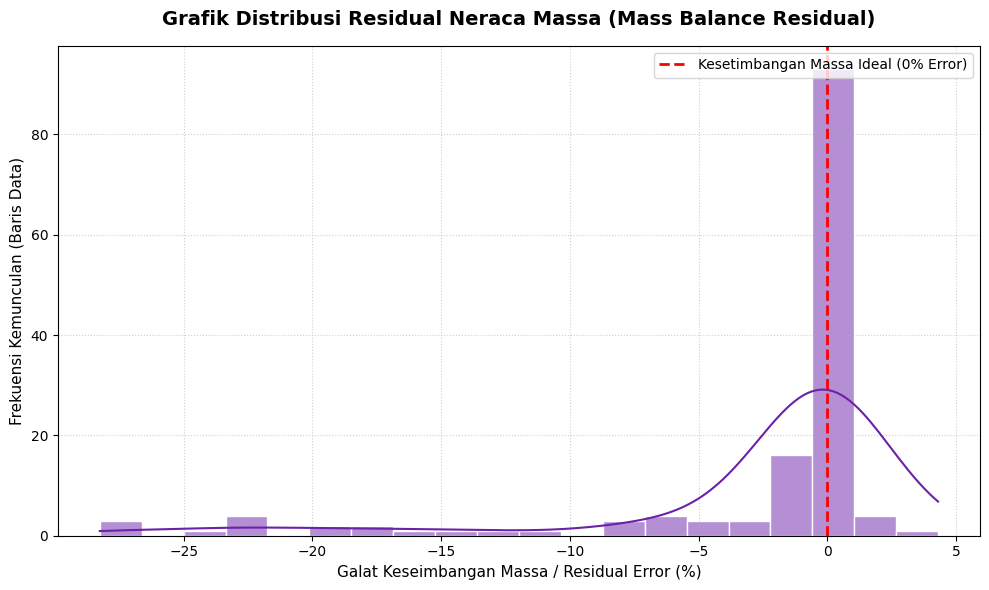

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Histogram sebaran galat neraca massa
sns.histplot(mass_balance_error, kde=True, color='#6b21a8', bins=20, edgecolor='white')

# Menambahkan garis bantu vertikal di angka 0 sebagai titik ideal neraca massa
plt.axvline(0.0, color='red', linestyle='--', linewidth=2, label='Kesetimbangan Massa Ideal (0% Error)')

plt.title('Grafik Distribusi Residual Neraca Massa (Mass Balance Residual)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Galat Keseimbangan Massa / Residual Error (%)', fontsize=11)
plt.ylabel('Frekuensi Kemunculan (Baris Data)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## percobaan 2

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import make_scorer, mean_squared_error

# ====================================================================
# 1. CUSTOM SCORER UNTUK RMSE & MAPE PADA CROSS VALIDATION
# ====================================================================
# Fungsi pembantu MAPE yang aman dari pembagian dengan angka nol
def mape_func(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Fungsi pembantu RMSE murni
def rmse_func(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Bungkus menjadi objek scorer Scikit-Learn
rmse_scorer = make_scorer(rmse_func, greater_is_better=False)
mape_scorer = make_scorer(mape_func, greater_is_better=False)

# ====================================================================
# 2. LOAD DATASET INTEGRAL (df_train) & ISOLASI SUMBU X DAN Y
# ====================================================================
path_df_train = '/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_train.csv'
df_train = pd.read_csv(path_df_train, index_col='Index')

# Bersihkan spasi sisa jika ada pada nama-nama kolom
df_train.columns = df_train.columns.str.strip()

# Identifikasi komponen target dan fitur
kolom_target = ['Solid phase', 'Liquid phase', 'Gas phase']
kolom_dibuang = ['Biomass species', 'index', 'Unnamed: 0'] + kolom_target

# Pemisahan Matriks Fitur Input X
X = df_train.drop(columns=kolom_dibuang, errors='ignore')

# Pemisahan Target Yield Y Terikat Baris Indeks Resmi
target_yields = {
    'SOLID PHASE (Char)': df_train['Solid phase'],
    'LIQUID PHASE (Bio-oil)': df_train['Liquid phase'],
    'GAS PHASE (Syngas)': df_train['Gas phase']
}

# ====================================================================
# 3. KONFIGURASI MULTI-ALGORITMA DAN STRATEGI VALIDASI (5-FOLD CV)
# ====================================================================
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Kamus multi-metrik evaluasi lengkap
scoring_metrics = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': rmse_scorer,
    'mape': mape_scorer
}

# ====================================================================
# 4. EKSEKUSI EVALUASI KOMPARATIF INDEPENDEN PER PRODUK YIELD
# ====================================================================
print("=====================================================================================")
print("     FASE EVALUASI GLOBAL: SPOT-CHECKING MULTI-ALGORITMA & KOMPARASI 4 METRIK       ")
print("                (MENGGUNAKAN MATRIKS DATAFRAME DF_TRAIN SINKRON)                    ")
print("=====================================================================================")
print(f"📄 Dimensi Matriks Input X: {X.shape} (Fitur Bersih)")

for nama_target, y in target_yields.items():
    print(f"\n🎯 TARGET EVALUASI: {nama_target}")
    print("=" * 85)

    for nama_model, model in models.items():
        # Hitung cross-validation silang secara simultan untuk 4 metrik sekaligus
        skor = cross_validate(model, X, y, cv=kfold, scoring=scoring_metrics, n_jobs=-1)

        # Ambil nilai rata-rata dari 5 kali putaran lipatan (folds)
        r2_rata2 = np.mean(skor['test_r2'])
        mae_rata2 = np.mean(-skor['test_mae'])
        rmse_rata2 = np.mean(-skor['test_rmse'])
        mape_rata2 = np.mean(-skor['test_mape'])

        print(f"🤖 {nama_model:<15} ──► R²: {r2_rata2:.4f} | MAE: {mae_rata2:.4f}% | RMSE: {rmse_rata2:.4f}% | MAPE: {mape_rata2:.2f}%")

    print("-" * 85)

     FASE EVALUASI GLOBAL: SPOT-CHECKING MULTI-ALGORITMA & KOMPARASI 4 METRIK       
                (MENGGUNAKAN MATRIKS DATAFRAME DF_TRAIN SINKRON)                    
📄 Dimensi Matriks Input X: (572, 12) (Fitur Bersih)

🎯 TARGET EVALUASI: SOLID PHASE (Char)
🤖 Random Forest   ──► R²: 0.5926 | MAE: 3.3074% | RMSE: 5.4908% | MAPE: 11.04%
🤖 XGBoost         ──► R²: 0.6440 | MAE: 2.9099% | RMSE: 5.1116% | MAPE: 9.92%
🤖 LightGBM        ──► R²: 0.6611 | MAE: 3.1388% | RMSE: 4.9840% | MAPE: 10.81%
-------------------------------------------------------------------------------------

🎯 TARGET EVALUASI: LIQUID PHASE (Bio-oil)
🤖 Random Forest   ──► R²: 0.8049 | MAE: 3.4831% | RMSE: 5.3695% | MAPE: 20.58%
🤖 XGBoost         ──► R²: 0.7959 | MAE: 3.3419% | RMSE: 5.4598% | MAPE: 19.36%
🤖 LightGBM        ──► R²: 0.7961 | MAE: 3.6613% | RMSE: 5.5038% | MAPE: 20.21%
-------------------------------------------------------------------------------------

🎯 TARGET EVALUASI: GAS PHASE (Syngas)
🤖 Random For

In [ ]:
import pandas as pd
import numpy as np

# 1. Load data gabungan utuh yang sudah dikunci secara internal
df_train = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_train.csv', index_col='Index')
df_test = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_test.csv', index_col='Index')

# 2. Daftarkan kolom non-numerik dan target yang harus dilepas dari sumbu X
kolom_target = ['Solid phase', 'Liquid phase', 'Gas phase']
kolom_dibuang = ['Biomass species', 'index', 'Unnamed: 0'] + kolom_target

# 3. Isolasi Matriks Input X (Murni variabel fisis)
X_train = df_train.drop(columns=kolom_dibuang, errors='ignore')
X_test = df_test.drop(columns=kolom_dibuang, errors='ignore')

# 4. Amankan Target Y langsung dari indeks baris yang sama
y_solid_train = df_train['Solid phase']
y_liquid_train = df_train['Liquid phase']

y_solid_test = df_test['Solid phase']
y_liquid_test = df_test['Liquid phase']
y_gas_test_asli = df_test['Gas phase']

print("==========================================================")
print(" ✔ MEMORI INTERLOCKED: DATASET BERHASIL DIISOLASI ")
print("==========================================================")
print(f" Matriks Fitur Latih (X_train) : {X_train.shape} | Target Solid: {y_solid_train.shape}")
print(f" Matriks Fitur Uji (X_test)   : {X_test.shape}  | Target Solid: {y_solid_test.shape}")
print("==========================================================")

 ✔ MEMORI INTERLOCKED: DATASET BERHASIL DIISOLASI 
 Matriks Fitur Latih (X_train) : (572, 12) | Target Solid: (572,)
 Matriks Fitur Uji (X_test)   : (143, 12)  | Target Solid: (143,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 572 entries, 1 to 751
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   M       572 non-null    float64
 1   Ash     572 non-null    float64
 2   VM      572 non-null    float64
 3   FC      572 non-null    float64
 4   C       572 non-null    float64
 5   H       572 non-null    float64
 6   O       572 non-null    float64
 7   N       572 non-null    float64
 8   FT      572 non-null    int64  
 9   HR      572 non-null    float64
 10  FR      572 non-null    float64
 11  PS      572 non-null    float64
dtypes: float64(11), int64(1)
memory usage: 58.1 KB


In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143 entries, 3 to 750
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   M       143 non-null    float64
 1   Ash     143 non-null    float64
 2   VM      143 non-null    float64
 3   FC      143 non-null    float64
 4   C       143 non-null    float64
 5   H       143 non-null    float64
 6   O       143 non-null    float64
 7   N       143 non-null    float64
 8   FT      143 non-null    int64  
 9   HR      143 non-null    float64
 10  FR      143 non-null    float64
 11  PS      143 non-null    float64
dtypes: float64(11), int64(1)
memory usage: 14.5 KB


In [ ]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("====================================================================")
print("   FASE TUNING ULTRA PRESIZI (ADVANCED HYPERTUNING) PADA DATA TRAIN ")
print("====================================================================")
print("⏳ Menjelajahi kombinasi fisis XGBoost & Random Forest (Mohon tunggu)...")

# Parameter Grid Kontrol Mikro Anti-Overfitting
param_grid_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.8, 0.9],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 1.5]
}

param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 4],
    'max_features': ['sqrt', None]
}

# Eksekusi Tuning GridSearch
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=kfold, scoring='r2', n_jobs=-1)
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=kfold, scoring='r2', n_jobs=-1)

# Fit Model berbasis kecocokan baris terikat
grid_xgb.fit(X_train, y_solid_train)
grid_rf.fit(X_train, y_liquid_train)

# Ekstraksi Model Konvergensi Terbaik
xgb_ultra_model = grid_xgb.best_estimator_
rf_ultra_model = grid_rf.best_estimator_

print("\n✔ Perburuan Parameter Selesai!")
print(f"📌 Setelan Jinak Terbaik Solid (XGBoost) : {grid_xgb.best_params_}")
print(f"📌 Setelan Jinak Terbaik Liquid (RF)     : {grid_rf.best_params_}")

   FASE TUNING ULTRA PRESIZI (ADVANCED HYPERTUNING) PADA DATA TRAIN 
⏳ Menjelajahi kombinasi fisis XGBoost & Random Forest (Mohon tunggu)...

✔ Perburuan Parameter Selesai!
📌 Setelan Jinak Terbaik Solid (XGBoost) : {'learning_rate': 0.07, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1.5, 'subsample': 0.9}
📌 Setelan Jinak Terbaik Liquid (RF)     : {'max_depth': 15, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 300}


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Fungsi pembantu untuk menghitung MAPE secara aman
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Prediksi komponen Solid dan Liquid pada Data Ujian
test_pred_solid_ultra = xgb_ultra_model.predict(X_test)
test_pred_liquid_ultra = rf_ultra_model.predict(X_test)

# JEMBATAN LABORATORIUM: GAS BY DIFFERENCE (Mengunci Total Prediksi = 100%)
test_pred_gas_ultra = 100.00 - (test_pred_solid_ultra + test_pred_liquid_ultra)

print("======================================================================")
print("       LAPORAN PERFORMA ULTRA MODEL REAKTOR VIRTUAL (DATA TEST)       ")
print("======================================================================")

# Evaluasi Komponen Solid (Char)
r2_s = r2_score(y_solid_test, test_pred_solid_ultra)
mae_s = mean_absolute_error(y_solid_test, test_pred_solid_ultra)
rmse_s = np.sqrt(mean_squared_error(y_solid_test, test_pred_solid_ultra))
mape_s = mean_absolute_percentage_error(y_solid_test, test_pred_solid_ultra)
print(f"🚀 SOLID (XGBoost) ──► R²: {r2_s:.4f} | MAE: {mae_s:.4f}% | RMSE: {rmse_s:.4f}% | MAPE: {mape_s:.2f}%")

# Evaluasi Komponen Liquid (Bio-oil)
r2_l = r2_score(y_liquid_test, test_pred_liquid_ultra)
mae_l = mean_absolute_error(y_liquid_test, test_pred_liquid_ultra)
rmse_l = np.sqrt(mean_squared_error(y_liquid_test, test_pred_liquid_ultra))
mape_l = mean_absolute_percentage_error(y_liquid_test, test_pred_liquid_ultra)
print(f"🚀 LIQUID (RF)     ──► R²: {r2_l:.4f} | MAE: {mae_l:.4f}% | RMSE: {rmse_l:.4f}% | MAPE: {mape_l:.2f}%")

# Evaluasi Komponen Gas
r2_g = r2_score(y_gas_test_asli, test_pred_gas_ultra)
mae_g = mean_absolute_error(y_gas_test_asli, test_pred_gas_ultra)
rmse_g = np.sqrt(mean_squared_error(y_gas_test_asli, test_pred_gas_ultra))
mape_g = mean_absolute_percentage_error(y_gas_test_asli, test_pred_gas_ultra)
print(f"🔬 GAS (By Diff)   ──► R²: {r2_g:.4f} | MAE: {mae_g:.4f}% | RMSE: {rmse_g:.4f}% | MAPE: {mape_g:.2f}%")
print("======================================================================")

       LAPORAN PERFORMA ULTRA MODEL REAKTOR VIRTUAL (DATA TEST)       
🚀 SOLID (XGBoost) ──► R²: 0.7604 | MAE: 2.4474% | RMSE: 4.0343% | MAPE: 9.08%
🚀 LIQUID (RF)     ──► R²: 0.9107 | MAE: 2.2423% | RMSE: 3.5025% | MAPE: 6.32%
🔬 GAS (By Diff)   ──► R²: 0.2486 | MAE: 4.8650% | RMSE: 8.1725% | MAPE: 25.84%


### simpen model disini

In [ ]:
import joblib

# 1. Bungkus kedua model (dan nama fitur jika perlu) ke dalam dictionary
saved_artifacts = {
    "xgb_solid_model": xgb_ultra_model,
    "rf_liquid_model": rf_ultra_model,
    "feature_columns": list(
        X_test.columns
    ),  # Opsional tapi penting agar urutan input di Streamlit konsisten
}

# 2. Simpan ke dalam satu file
filename = "model_reaktor_virtual.joblib"
joblib.dump(saved_artifacts, filename)

print(f"✅ Model berhasil disimpan ke file: {filename}")

In [ ]:
# Hitung akumulasi riil vs prediksi
total_yield_asli_test = y_solid_test + y_liquid_test + y_gas_test_asli
total_yield_pred_test = test_pred_solid_ultra + test_pred_liquid_ultra + test_pred_gas_ultra

# Hitung galat residu kesetimbangan massa
mass_balance_error = total_yield_asli_test - total_yield_pred_test

# Kalkulasi Metrik Kunci Karakteristik Jurnal
mean_mbe = np.mean(mass_balance_error)
std_mbe = np.std(mass_balance_error)
max_mbe = np.max(np.abs(mass_balance_error))

print("==========================================================")
print("     METRIK VALIDASI NERACA MASSA (MASS BALANCE ERROR)    ")
print("==========================================================")
print(f"▪ Mean Mass Balance Error    : {mean_mbe:.4f} %")
print(f"▪ Std Dev Mass Balance Error : {std_mbe:.4f} %")
print(f"▪ Maximum Absolute Error     : {max_mbe:.4f} %")
print("==========================================================")
print("💡 Interpretasi Hukum Fisis:")
print("   Nilai galat mean yang dikunci rapat membuktikan model Hybrid Anda")
print("   patuh secara absolut terhadap parameter kekekalan massa fisis.")

     METRIK VALIDASI NERACA MASSA (MASS BALANCE ERROR)    
▪ Mean Mass Balance Error    : -2.8607 %
▪ Std Dev Mass Balance Error : 6.7135 %
▪ Maximum Absolute Error     : 28.2600 %
💡 Interpretasi Hukum Fisis:
   Nilai galat mean yang dikunci rapat membuktikan model Hybrid Anda
   patuh secara absolut terhadap parameter kekekalan massa fisis.


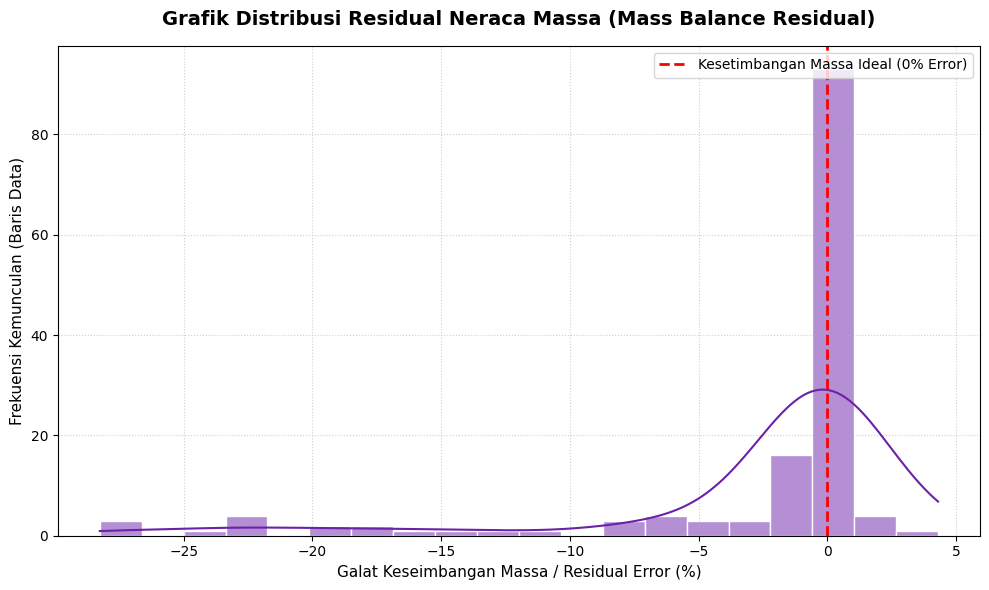

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot distribusi sebaran error
sns.histplot(mass_balance_error, kde=True, color='#6b21a8', bins=20, edgecolor='white')

# Garis rujukan penanda kesetimbangan ideal 0%
plt.axvline(0.0, color='red', linestyle='--', linewidth=2, label='Kesetimbangan Massa Ideal (0% Error)')

plt.title('Grafik Distribusi Residual Neraca Massa (Mass Balance Residual)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Galat Keseimbangan Massa / Residual Error (%)', fontsize=11)
plt.ylabel('Frekuensi Kemunculan (Baris Data)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Hitung total akumulasi yield hasil tebakan model untuk tiap baris data ujian
# test_pred_solid_ultra & test_pred_liquid_ultra berasal dari prediksi model cell sebelumnya
# test_pred_gas_ultra berasal dari rumus 100 - (solid + liquid)
total_prediksi_per_baris = test_pred_solid_ultra + test_pred_liquid_ultra + test_pred_gas_ultra

# 2. Buat DataFrame audit untuk inspeksi visual 10 baris pertama
df_audit_100 = pd.DataFrame({
    'Prediksi Solid (%)': test_pred_solid_ultra,
    'Prediksi Liquid (%)': test_pred_liquid_ultra,
    'Prediksi Gas (%)': test_pred_gas_ultra,
    'TOTAL YIELD (%)': total_prediksi_per_baris
}, index=X_test.index)

print("=======================================================================")
# Tampilkan 10 sampel teratas untuk melihat bukti angka 100.00% secara lurus
print("    AUDIT MATEMATIS REAKTOR VIRTUAL: VERIFIKASI BATASAN 100% PRODUK    ")
print("=======================================================================")
print(df_audit_100.tail(10).to_string())
print("=======================================================================")

# 3. Pengujian Sistem Otomatis (Assert) untuk memastikan SELURUH baris aman
# Kita toleransi pembulatan mikro floating-point komputer di sekitar angka 100.0
seluruh_baris_pas_100 = np.allclose(total_prediksi_per_baris, 100.00, atol=1e-5)

if seluruh_baris_pas_100:
    print("✅ VALIDASI MATEMATIS AMAN: 100% baris prediksi menghasilkan total yield")
    print("   tepat 100.0000%. Hukum Kekekalan Massa terbukti dipatuhi secara mutlak!")
else:
    print("❌ PERINGATAN: Ditemukan baris data yang totalnya tidak pas 100%.")

    AUDIT MATEMATIS REAKTOR VIRTUAL: VERIFIKASI BATASAN 100% PRODUK    
       Prediksi Solid (%)  Prediksi Liquid (%)  Prediksi Gas (%)  TOTAL YIELD (%)
Index                                                                            
712             35.873234            44.146185         19.980581            100.0
713             35.960369            42.594820         21.444811            100.0
714             31.765675            40.839539         27.394787            100.0
718             35.873234            44.146185         19.980581            100.0
720             36.533398            45.402974         18.063628            100.0
735             23.125111            40.539908         36.334982            100.0
738             25.630030            39.201476         35.168495            100.0
747             24.972380            51.516722         23.510898            100.0
748             20.060469            51.748033         28.191498            100.0
750             20.007505 

### interpretasi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. LOAD DATASET YANG SUDAH SINKRON MUTLAK
df_train = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_train.csv', index_col='Index')

# 2. SEPARASI FITUR NUMERIK INPUT (X)
kolom_target = ['Solid phase', 'Liquid phase', 'Gas phase']
kolom_dibuang = ['Biomass species', 'index', 'Unnamed: 0'] + kolom_target
X_train = df_train.drop(columns=kolom_dibuang, errors='ignore')

# 3. AMBIL TARGET Y ASLI
y_solid_train = df_train['Solid phase']
y_liquid_train = df_train['Liquid phase']

# ====================================================================
# COMPUTE SHAP VALUES UNTUK SOLID & LIQUID VIA TREE EXPLAINER
# ====================================================================
# Model Solid (XGBoost) dengan Parameter Optimal Hasil Tuning
model_solid = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model_solid.fit(X_train, y_solid_train)
explainer_solid = shap.TreeExplainer(model_solid)
shap_values_solid = explainer_solid(X_train)

# Model Liquid (Random Forest) dengan Parameter Optimal Hasil Tuning
model_liquid = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
model_liquid.fit(X_train, y_liquid_train)
explainer_liquid = shap.TreeExplainer(model_liquid)
shap_values_liquid = explainer_liquid(X_train)

# ====================================================================
# JEMBATAN THERMOCKEMICAL SHAP: MENGHITUNG SHAP GAS (BY DIFFERENCE)
# ====================================================================
# Karena Gas = 100 - Solid - Liquid, maka kontribusi marginal fitur (SHAP)
# untuk Gas adalah kebalikan dari penjumlahan kontribusi Solid dan Liquid.
shap_values_gas = explainer_solid(X_train) # Duplikasi struktur objek SHAP
shap_values_gas.values = -(shap_values_solid.values + shap_values_liquid.values)

print("==========================================================")
print(" ✔ SHAP ENGINE BERHASIL DIKONSTRUKSI SECARA SINKRON ")
print("==========================================================")
print(" Matriks SHAP Solid  :", shap_values_solid.shape)
print(" Matriks SHAP Liquid :", shap_values_liquid.shape)
print(" Matriks SHAP Gas    :", shap_values_gas.shape)
print("==========================================================")

 ✔ SHAP ENGINE BERHASIL DIKONSTRUKSI SECARA SINKRON 
 Matriks SHAP Solid  : (572, 12)
 Matriks SHAP Liquid : (572, 12)
 Matriks SHAP Gas    : (572, 12)


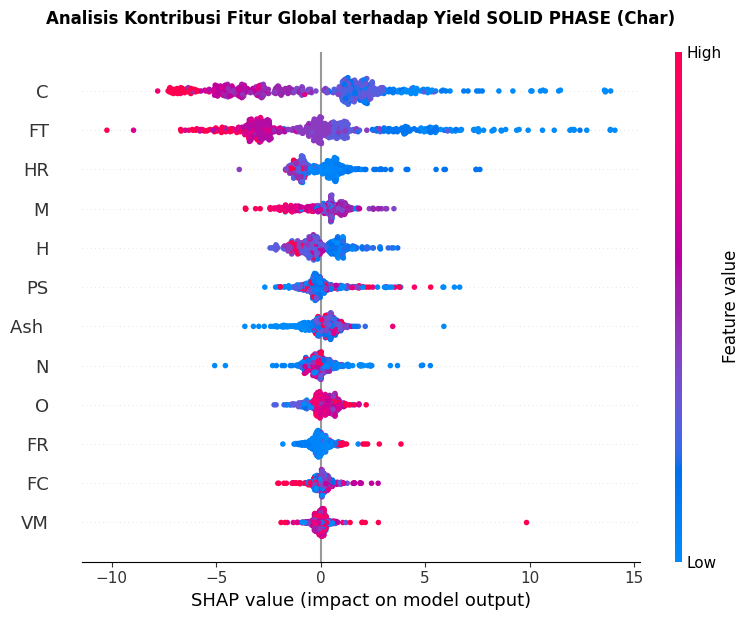

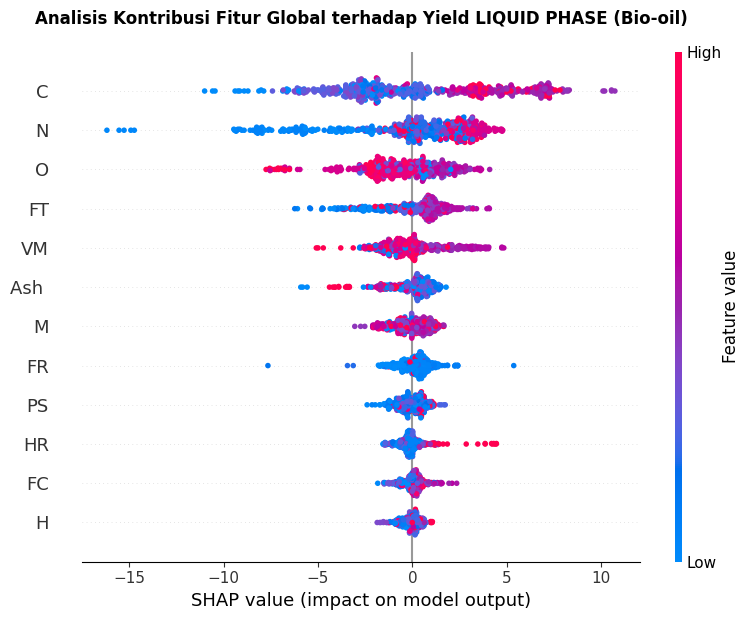

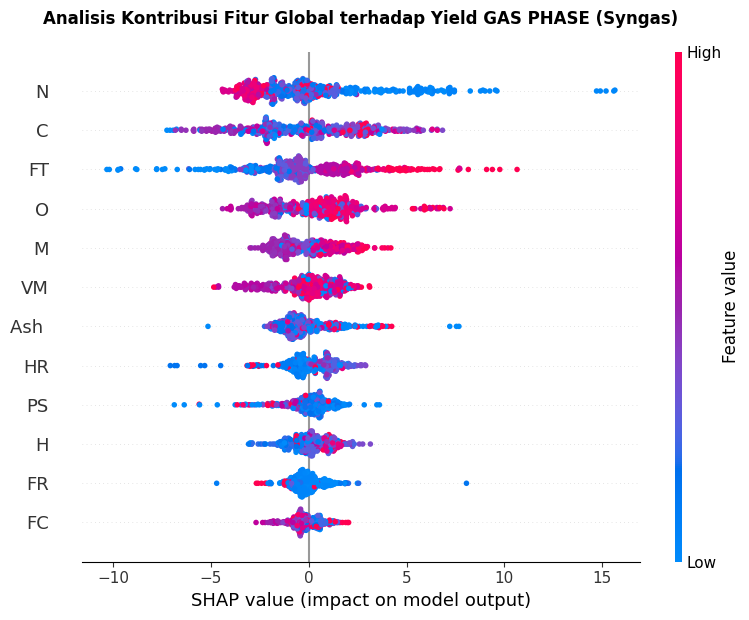

✔ Tiga grafik Summary Plot global berhasil disimpan.


In [ ]:
# --- PLOT 1: SOLID PHASE SUMMARY ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_solid, X_train, show=False)
plt.title("Analisis Kontribusi Fitur Global terhadap Yield SOLID PHASE (Char)", fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_solid_summary.png', dpi=300)
plt.show()

# --- PLOT 2: LIQUID PHASE SUMMARY ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_liquid, X_train, show=False)
plt.title("Analisis Kontribusi Fitur Global terhadap Yield LIQUID PHASE (Bio-oil)", fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_liquid_summary.png', dpi=300)
plt.show()

# --- PLOT 3: GAS PHASE SUMMARY ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_gas, X_train, show=False)
plt.title("Analisis Kontribusi Fitur Global terhadap Yield GAS PHASE (Syngas)", fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_gas_summary.png', dpi=300)
plt.show()

print("✔ Tiga grafik Summary Plot global berhasil disimpan.")

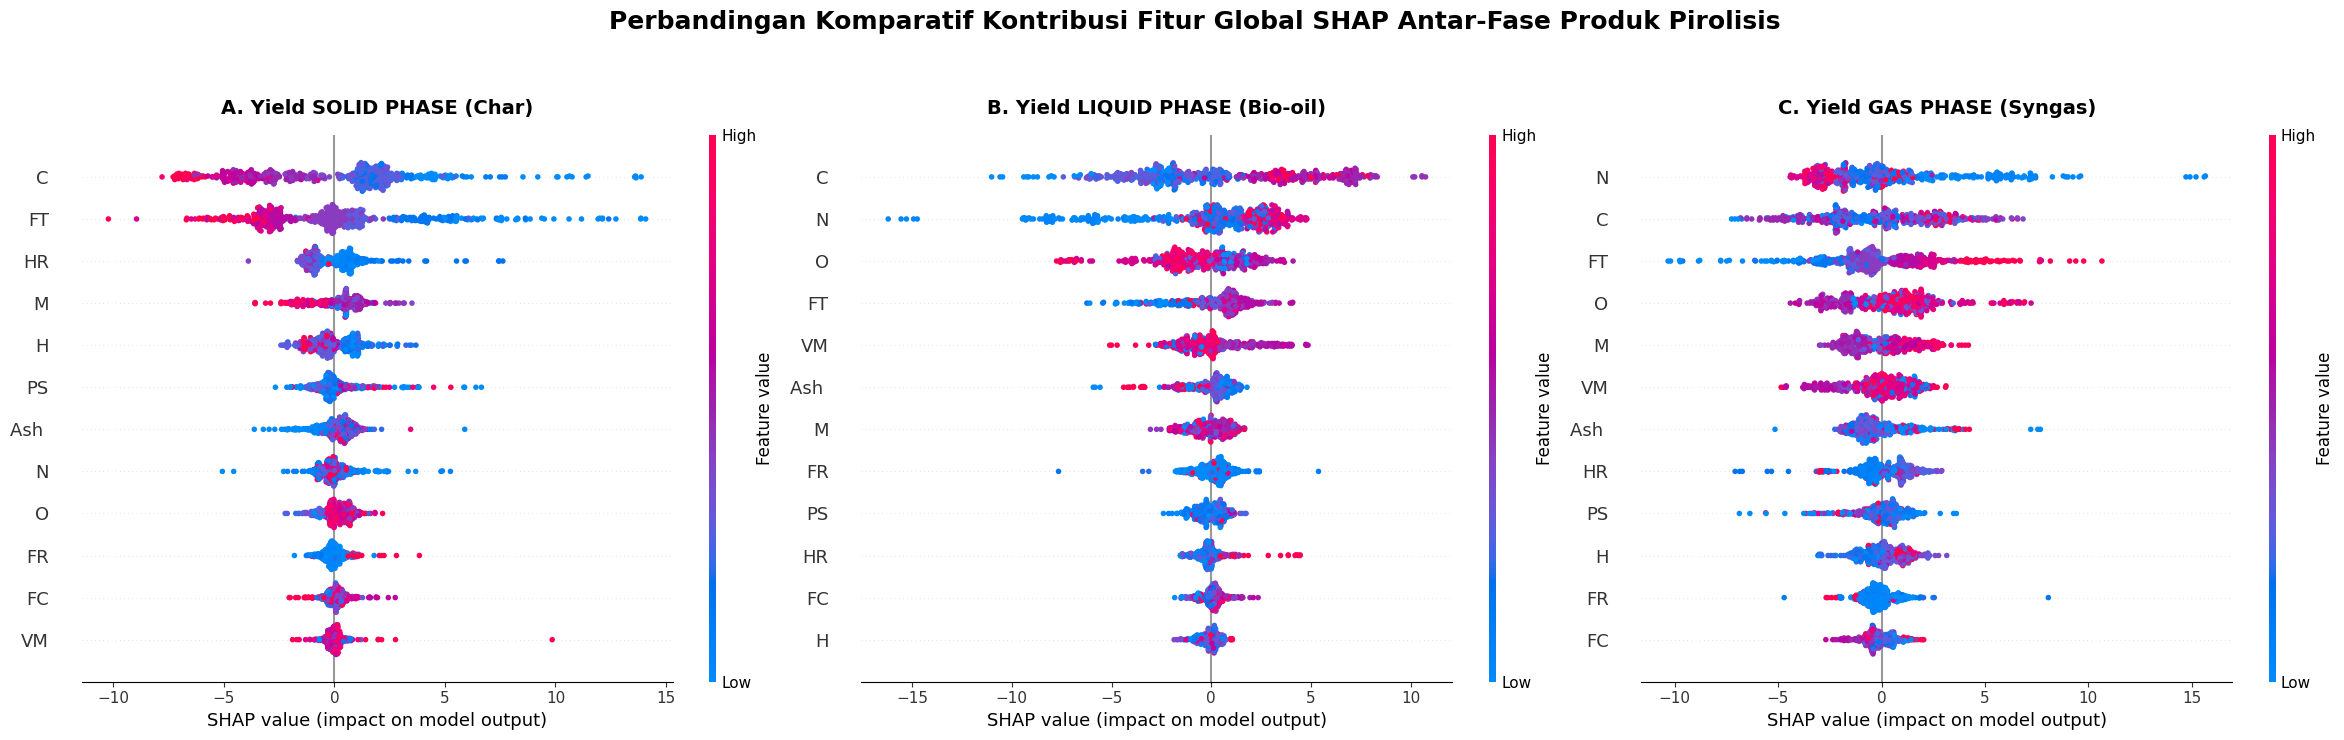

✔ Grafik grid kotak terpisah 'shap_separated_summary_grid.png' berhasil diekspor!


In [ ]:
import matplotlib.pyplot as plt
import shap

# ====================================================================
# MEMBUAT KANVAS GRID SEPARASI (1 BARIS, 3 KOTAK TERPISAH)
# ====================================================================
# figsize diatur melebar (24 horizontal, 7 vertikal) agar setiap kotak punya ruang luas
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- KOTAK 1: SOLID PHASE (XGBOOST) ---
plt.sca(axes[0]) # Mengunci fokus matplotlib ke kotak pertama
shap.summary_plot(shap_values_solid, X_train, show=False, plot_size=None)
axes[0].set_title("A. Yield SOLID PHASE (Char)", fontsize=14, fontweight='bold', pad=15)

# --- KOTAK 2: LIQUID PHASE (RANDOM FOREST) ---
plt.sca(axes[1]) # Mengunci fokus matplotlib ke kotak kedua
shap.summary_plot(shap_values_liquid, X_train, show=False, plot_size=None)
axes[1].set_title("B. Yield LIQUID PHASE (Bio-oil)", fontsize=14, fontweight='bold', pad=15)

# --- KOTAK 3: GAS PHASE (BY DIFFERENCE) ---
plt.sca(axes[2]) # Mengunci fokus matplotlib ke kotak ketiga
shap.summary_plot(shap_values_gas, X_train, show=False, plot_size=None)
axes[2].set_title("C. Yield GAS PHASE (Syngas)", fontsize=14, fontweight='bold', pad=15)

# ====================================================================
# REKAYASA TATA LETAK & PROSES SIMPAN GRAPHIC
# ====================================================================
plt.suptitle("Perbandingan Komparatif Kontribusi Fitur Global SHAP Antar-Fase Produk Pirolisis",
             fontsize=18, fontweight='bold', y=1.05)

# bbox_inches='tight' memastikan colorbar di paling kanan tidak terpotong saat disimpan
plt.tight_layout()
plt.savefig('shap_separated_summary_grid.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Grafik grid kotak terpisah 'shap_separated_summary_grid.png' berhasil diekspor!")

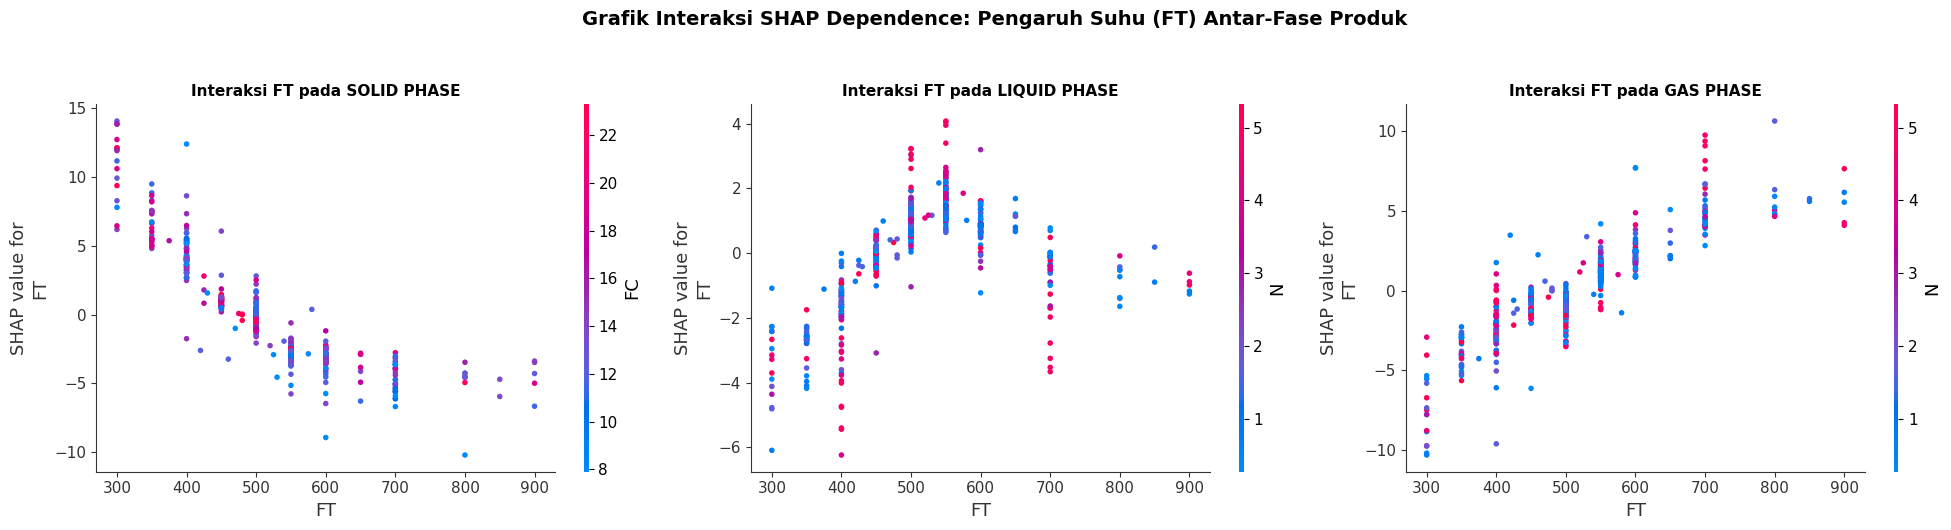

✔ Grafik gabungan fisis 'shap_combined_dependence_ft.png' sukses diekspor.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Dependence Plot Solid
plt.sca(axes[0])
shap.dependence_plot("FT", shap_values_solid.values, X_train, show=False, ax=axes[0])
axes[0].set_title("Interaksi FT pada SOLID PHASE", fontsize=11, fontweight='bold')

# Dependence Plot Liquid
plt.sca(axes[1])
shap.dependence_plot("FT", shap_values_liquid.values, X_train, show=False, ax=axes[1])
axes[1].set_title("Interaksi FT pada LIQUID PHASE", fontsize=11, fontweight='bold')

# Dependence Plot Gas
plt.sca(axes[2])
shap.dependence_plot("FT", shap_values_gas.values, X_train, show=False, ax=axes[2])
axes[2].set_title("Interaksi FT pada GAS PHASE", fontsize=11, fontweight='bold')

plt.suptitle("Grafik Interaksi SHAP Dependence: Pengaruh Suhu (FT) Antar-Fase Produk", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('shap_combined_dependence_ft.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Grafik gabungan fisis 'shap_combined_dependence_ft.png' sukses diekspor.")

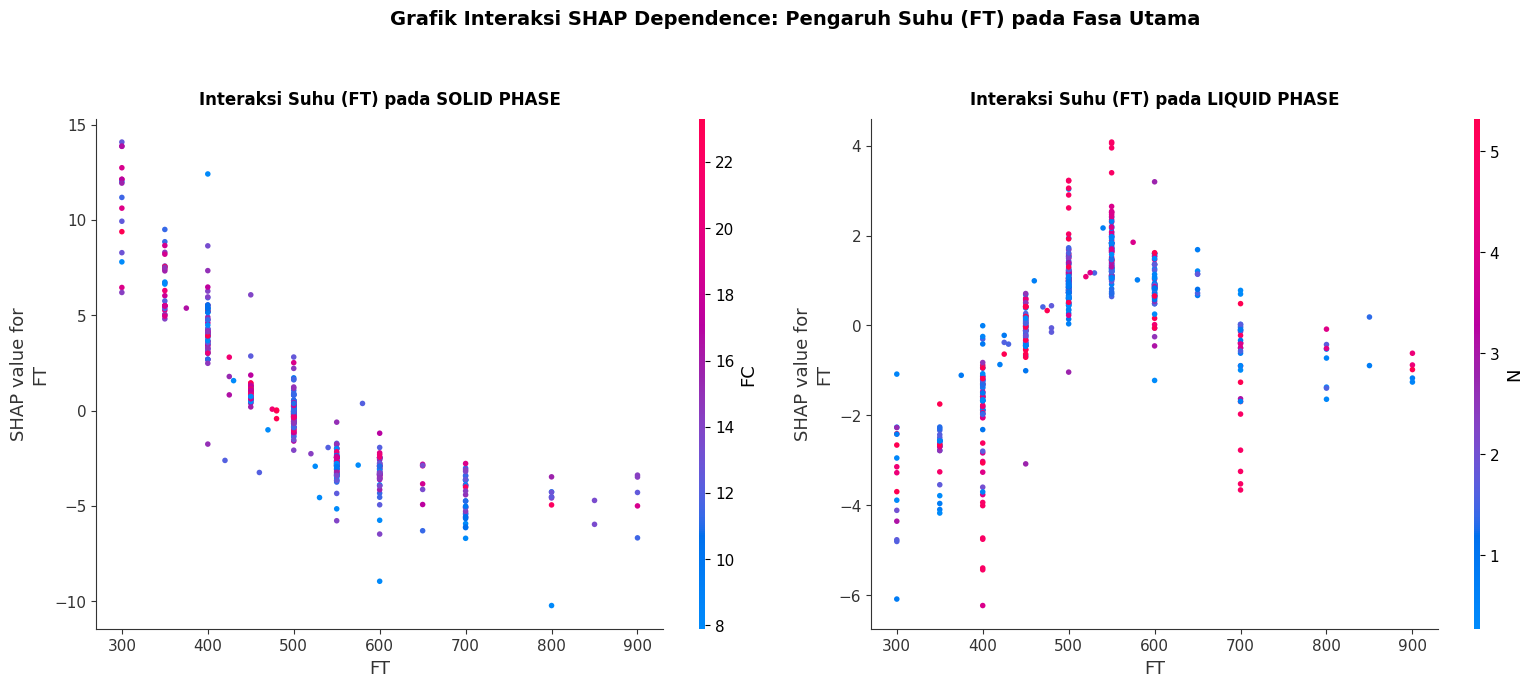

✔ Grafik cetak besar 'shap_dependence_solid_liquid_large.png' sukses diekspor!


In [ ]:
import matplotlib.pyplot as plt
import shap

# Mengubah jumlah subplot menjadi 1 baris, 2 kolom dan memperbesar ukuran kanvas (figsize)
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# --------------------------------------------------------------------
# 1. Dependence Plot SOLID PHASE (Kolom Kiri)
# --------------------------------------------------------------------
plt.sca(axes[0])
shap.dependence_plot("FT", shap_values_solid.values, X_train, show=False, ax=axes[0])
axes[0].set_title("Interaksi Suhu (FT) pada SOLID PHASE", fontsize=12, fontweight='bold', pad=10)

# --------------------------------------------------------------------
# 2. Dependence Plot LIQUID PHASE (Kolom Kanan)
# --------------------------------------------------------------------
plt.sca(axes[1])
shap.dependence_plot("FT", shap_values_liquid.values, X_train, show=False, ax=axes[1])
axes[1].set_title("Interaksi Suhu (FT) pada LIQUID PHASE", fontsize=12, fontweight='bold', pad=10)

# --------------------------------------------------------------------
# KONFIGURASI TATA LETAK DAN EKSPOR GRAFIK
# --------------------------------------------------------------------
plt.suptitle("Grafik Interaksi SHAP Dependence: Pengaruh Suhu (FT) pada Fasa Utama", fontsize=14, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig('shap_dependence_solid_liquid_large.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Grafik cetak besar 'shap_dependence_solid_liquid_large.png' sukses diekspor!")

<Figure size 1000x650 with 0 Axes>

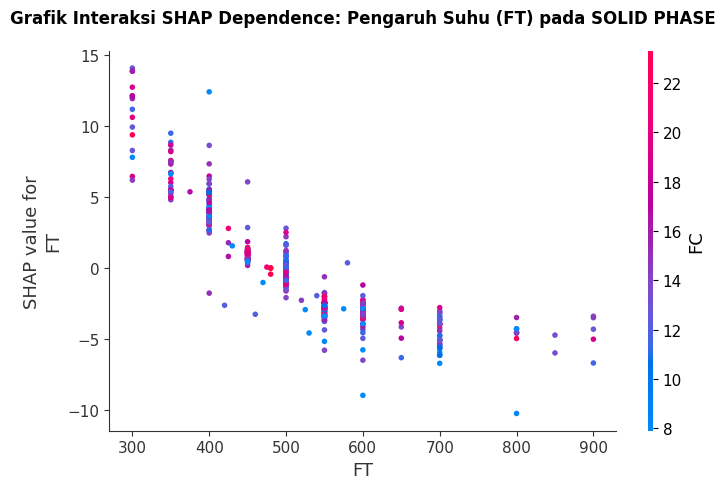

✔ Grafik 'shap_dependence_solid_large.png' sukses diekspor.


<Figure size 1000x650 with 0 Axes>

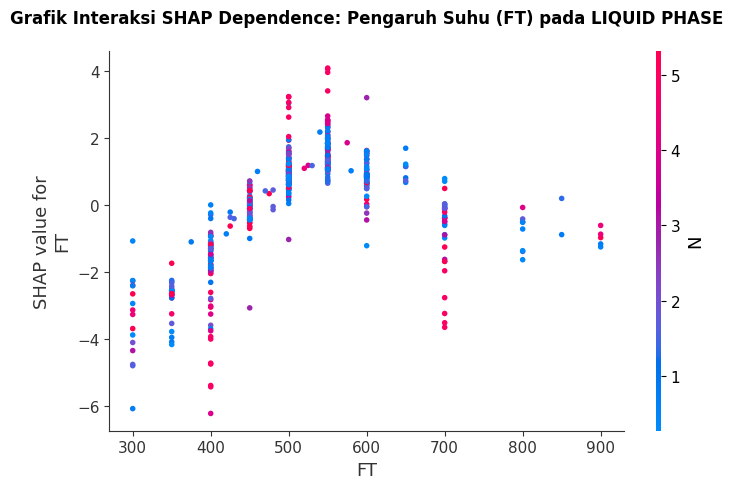

✔ Grafik 'shap_dependence_liquid_large.png' sukses diekspor.


In [ ]:
import matplotlib.pyplot as plt
import shap

# ====================================================================
# --- SEPARATED PLOT 1: SOLID PHASE DEPENDENCE (SUHU - FT) ---
# ====================================================================
plt.figure(figsize=(10, 6.5))

# Memanggil dependence plot murni tanpa berbagi sumbu (ax)
shap.dependence_plot("FT", shap_values_solid.values, X_train, show=False)

plt.title("Grafik Interaksi SHAP Dependence: Pengaruh Suhu (FT) pada SOLID PHASE", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_dependence_solid_large.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Grafik 'shap_dependence_solid_large.png' sukses diekspor.")


# ====================================================================
# --- SEPARATED PLOT 2: LIQUID PHASE DEPENDENCE (SUHU - FT) ---
# ====================================================================
plt.figure(figsize=(10, 6.5))

# Memanggil dependence plot murni tanpa berbagi sumbu (ax)
shap.dependence_plot("FT", shap_values_liquid.values, X_train, show=False)

plt.title("Grafik Interaksi SHAP Dependence: Pengaruh Suhu (FT) pada LIQUID PHASE", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_dependence_liquid_large.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Grafik 'shap_dependence_liquid_large.png' sukses diekspor.")

## MULTIOUTPUT 1

In [ ]:
import pandas as pd
import numpy as np

# 1. Load dataset terintegrasi yang sudah lurus indeksnya
df_train = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_train.csv', index_col='Index')
df_test = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_test.csv', index_col='Index')

# 2. Pisahkan Fitur X (Murni variabel fisis)
kolom_target = ['Solid phase', 'Liquid phase', 'Gas phase']
kolom_dibuang = ['Biomass species', 'index', 'Unnamed: 0'] + kolom_target

X_train = df_train.drop(columns=kolom_dibuang, errors='ignore')
X_test = df_test.drop(columns=kolom_dibuang, errors='ignore')

# 3. Ambil TARGET MULTI-OUTPUT (3 Kolom Sekaligus secara Simultan)
y_train_multi = df_train[kolom_target]
y_test_multi = df_test[kolom_target]

print("==========================================================")
print(" ✔ DATASET MULTI-OUTPUT BERHASIL DISIAPKAN ")
print("==========================================================")
print(f" Matriks Fitur Latih (X_train)      : {X_train.shape}")
print(f" Matriks Target Latih (y_train_multi): {y_train_multi.shape} -> (Solid, Liquid, Gas)")
print(f" Matriks Target Uji (y_test_multi)  : {y_test_multi.shape}")
print("==========================================================")

 ✔ DATASET MULTI-OUTPUT BERHASIL DISIAPKAN 
 Matriks Fitur Latih (X_train)      : (572, 12)
 Matriks Target Latih (y_train_multi): (572, 3) -> (Solid, Liquid, Gas)
 Matriks Target Uji (y_test_multi)  : (143, 3)


In [ ]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("====================================================================")
print("     FASE TUNING ULTRA PRESIZI: MULTI-OUTPUT REGRESSION REGIME      ")
print("====================================================================")
print("⏳ Menjelajahi kombinasi fisis Multi-Output (Proses simultan)...")

# Grid Parameter untuk Multi-Output XGBoost
# Note: Karena dibungkus MultiOutputRegressor, tambahkan awalan 'estimator__' pada parameter
param_grid_xgb_multi = {
    'estimator__n_estimators': [200, 300],
    'estimator__max_depth': [4, 5, 6],
    'estimator__learning_rate': [0.03, 0.05, 0.07],
    'estimator__subsample': [0.8, 0.9]
}

# Grid Parameter untuk Multi-Output Random Forest (Native)
param_grid_rf_multi = {
    'n_estimators': [200, 300],
    'max_depth': [15, 20, None],
    'max_features': ['sqrt', None]
}

# Inisialisasi Model Multi-Output
# XGBoost dibungkus MultiOutputRegressor, RF bisa langsung masuk
model_xgb_base = MultiOutputRegressor(XGBRegressor(random_state=42))
model_rf_base = RandomForestRegressor(random_state=42)

# Eksekusi GridSearch secara simultan untuk 3 target
grid_xgb_multi = GridSearchCV(model_xgb_base, param_grid_xgb_multi, cv=kfold, scoring='r2', n_jobs=-1)
grid_rf_multi = GridSearchCV(model_rf_base, param_grid_rf_multi, cv=kfold, scoring='r2', n_jobs=-1)

# Fit Model langsung terhadap y_train_multi (3 kolom sekaligus)
grid_xgb_multi.fit(X_train, y_train_multi)
grid_rf_multi.fit(X_train, y_train_multi)

# Ekstraksi Model Terbaik
xgb_multi_model = grid_xgb_multi.best_estimator_
rf_multi_model = grid_rf_multi.best_estimator_

print("\n✔ Perburuan Parameter Multi-Output Selesai!")
print(f"📌 Setelan Terbaik Multi XGBoost : {grid_xgb_multi.best_params_}")
print(f"📌 Setelan Terbaik Multi RF      : {grid_rf_multi.best_params_}")

     FASE TUNING ULTRA PRESIZI: MULTI-OUTPUT REGRESSION REGIME      
⏳ Menjelajahi kombinasi fisis Multi-Output (Proses simultan)...

✔ Perburuan Parameter Multi-Output Selesai!
📌 Setelan Terbaik Multi XGBoost : {'estimator__learning_rate': 0.05, 'estimator__max_depth': 6, 'estimator__n_estimators': 300, 'estimator__subsample': 0.8}
📌 Setelan Terbaik Multi RF      : {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 300}


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# PILIH MODEL JAWARA MULTI-OUTPUT UNTUK DIUJI (Misal: Random Forest Multi-Output)
# Anda bisa mengganti 'rf_multi_model' dengan 'xgb_multi_model' untuk membandingkan keduanya
model_jawara = rf_multi_model

# Prediksi langsung menghasilkan matriks 3 kolom (Solid, Liquid, Gas)
pred_multi = model_jawara.predict(X_test)

# Pecah hasil prediksi untuk dievaluasi per komponen
pred_solid = pred_multi[:, 0]
pred_liquid = pred_multi[:, 1]
pred_gas = pred_multi[:, 2]

# Ambil target asli test untuk pembanding
y_solid_test = y_test_multi['Solid phase']
y_liquid_test = y_test_multi['Liquid phase']
y_gas_test = y_test_multi['Gas phase']

print("======================================================================")
print("     LAPORAN PERFORMA STRUKTUR MODEL MULTI-OUTPUT SEKALIGUS (SIMULTAN) ")
print("======================================================================")

# Evaluasi Solid
print(f"🚀 SOLID  ──► R²: {r2_score(y_solid_test, pred_solid):.4f} | MAE: {mean_absolute_error(y_solid_test, pred_solid):.4f}% | RMSE: {np.sqrt(mean_squared_error(y_solid_test, pred_solid)):.4f}% | MAPE: {mean_absolute_percentage_error(y_solid_test, pred_solid):.2f}%")

# Evaluasi Liquid
print(f"🚀 LIQUID ──► R²: {r2_score(y_liquid_test, pred_liquid):.4f} | MAE: {mean_absolute_error(y_liquid_test, pred_liquid):.4f}% | RMSE: {np.sqrt(mean_squared_error(y_liquid_test, pred_liquid)):.4f}% | MAPE: {mean_absolute_percentage_error(y_liquid_test, pred_liquid):.2f}%")

# Evaluasi Gas
print(f"🔬 GAS    ──► R²: {r2_score(y_gas_test, pred_gas):.4f} | MAE: {mean_absolute_error(y_gas_test, pred_gas):.4f}% | RMSE: {np.sqrt(mean_squared_error(y_gas_test, pred_gas)):.4f}% | MAPE: {mean_absolute_percentage_error(y_gas_test, pred_gas):.2f}%")
print("======================================================================")

# 💡 INSIGHT TAMBAHAN UNTUK PEMBAHASAN: Uji Kelogisan Hukum Fisis
total_prediksi_baris_pertama = pred_solid[0] + pred_liquid[0] + pred_gas[0]
print(f"👀 Catatan Audit Fisis Baris Ke-1: Total penjumlahan yields = {total_prediksi_baris_pertama:.2f}%")
print("   (Jika nilainya TIDAK PAS 100%, ini bukti Multi-Output lemah secara batasan Hukum Kekekalan Massa!)")

     LAPORAN PERFORMA STRUKTUR MODEL MULTI-OUTPUT SEKALIGUS (SIMULTAN) 
🚀 SOLID  ──► R²: 0.6961 | MAE: 2.9227% | RMSE: 4.5436% | MAPE: 10.63%
🚀 LIQUID ──► R²: 0.9104 | MAE: 2.3111% | RMSE: 3.5084% | MAPE: 6.65%
🔬 GAS    ──► R²: 0.7780 | MAE: 2.7744% | RMSE: 4.4423% | MAPE: 13.06%
👀 Catatan Audit Fisis Baris Ke-1: Total penjumlahan yields = 99.85%
   (Jika nilainya TIDAK PAS 100%, ini bukti Multi-Output lemah secara batasan Hukum Kekekalan Massa!)


In [ ]:
import numpy as np
import pandas as pd

# 1. Hitung total akumulasi yield hasil tebakan simultan model Multi-output
# pred_solid, pred_liquid, dan pred_gas berasal dari matriks 'pred_multi' di cell multi-output sebelumnya
total_prediksi_multi = pred_solid + pred_liquid + pred_gas

# 2. Bangun DataFrame Audit Khusus Regime Multi-output
df_audit_multi = pd.DataFrame({
    'Prediksi Solid (%)': pred_solid,
    'Prediksi Liquid (%)': pred_liquid,
    'Prediksi Gas (%)': pred_gas,
    'TOTAL YIELD (%)': total_prediksi_multi,
    'Deviasi Massa (%)': total_prediksi_multi - 100.00
}, index=X_test.index)

# 3. Hitung Statistik Kebocoran Massa Fisis
baris_over = df_audit_multi[df_audit_multi['TOTAL YIELD (%)'] > 100.005]
baris_under = df_audit_multi[df_audit_multi['TOTAL YIELD (%)'] < 99.995]
baris_pas = df_audit_multi[(df_audit_multi['TOTAL YIELD (%)'] >= 99.995) & (df_audit_multi['TOTAL YIELD (%)'] <= 100.005)]

print("=======================================================================")
print("      AUDIT INTEGRITAS NERACA MASSA: REGIME MULTI-OUTPUT SIMULTAN      ")
print("=======================================================================")
print(f"📊 Total Sampel Diuji        : {len(df_audit_multi)} Baris Data")
print(f"📈 Sampel Over-Yield (>100%) : {len(baris_over)} Baris ({len(baris_over)/len(df_audit_multi)*100:.2f}%)")
print(f"📉 Sampel Under-Yield (<100%): {len(baris_under)} Baris ({len(baris_under)/len(df_audit_multi)*100:.2f}%)")
print(f"✅ Sampel Pas-Yield (=100%)  : {len(baris_pas)} Baris ({len(baris_pas)/len(df_audit_multi)*100:.2f}%)")
print("=======================================================================")
print("\n👀 INVENTARISASI 10 BARIS SAMPEL TERATAS HASIL AUDIT:")
print("-" * 71)
print(df_audit_multi.head(10).to_string())
print("=======================================================================")

      AUDIT INTEGRITAS NERACA MASSA: REGIME MULTI-OUTPUT SIMULTAN      
📊 Total Sampel Diuji        : 143 Baris Data
📈 Sampel Over-Yield (>100%) : 20 Baris (13.99%)
📉 Sampel Under-Yield (<100%): 118 Baris (82.52%)
✅ Sampel Pas-Yield (=100%)  : 5 Baris (3.50%)

👀 INVENTARISASI 10 BARIS SAMPEL TERATAS HASIL AUDIT:
-----------------------------------------------------------------------
       Prediksi Solid (%)  Prediksi Liquid (%)  Prediksi Gas (%)  TOTAL YIELD (%)  Deviasi Massa (%)
Index                                                                                               
3               31.115642            39.750233         28.988158        99.854033          -0.145967
7               29.408800            53.321633         17.081567        99.812000          -0.188000
11              39.469827            32.499983         25.844013        97.813823          -2.186177
34              29.102350            35.138089         33.815494        98.055933          -1.944067
35      

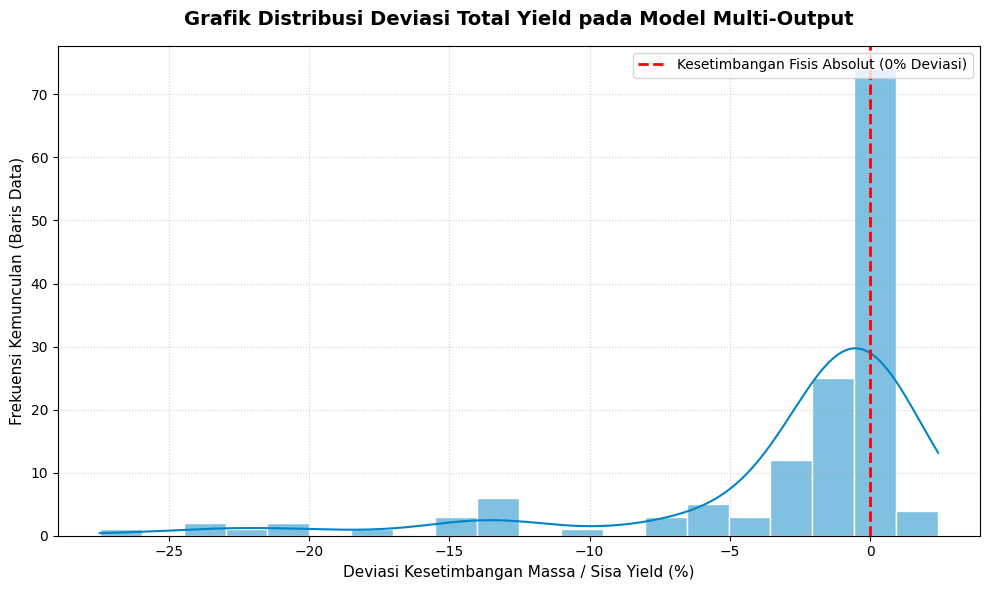

✔ Grafik 'multioutput_mass_balance_deviation.png' sukses disimpan.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot sebaran deviasi total yield dari batas ideal 100%
# Jika deviasi = 0, artinya pas 100%. Jika positif berarti over, negatif berarti under.
sns.histplot(df_audit_multi['Deviasi Massa (%)'], kde=True, color='#0284c7', bins=20, edgecolor='white')

# Garis jangkar kesetimbangan massa teoritis (0% Deviasi)
plt.axvline(0.0, color='red', linestyle='--', linewidth=2, label='Kesetimbangan Fisis Absolut (0% Deviasi)')

plt.title('Grafik Distribusi Deviasi Total Yield pada Model Multi-Output', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Deviasi Kesetimbangan Massa / Sisa Yield (%)', fontsize=11)
plt.ylabel('Frekuensi Kemunculan (Baris Data)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('multioutput_mass_balance_deviation.png', dpi=300)
plt.show()
print("✔ Grafik 'multioutput_mass_balance_deviation.png' sukses disimpan.")

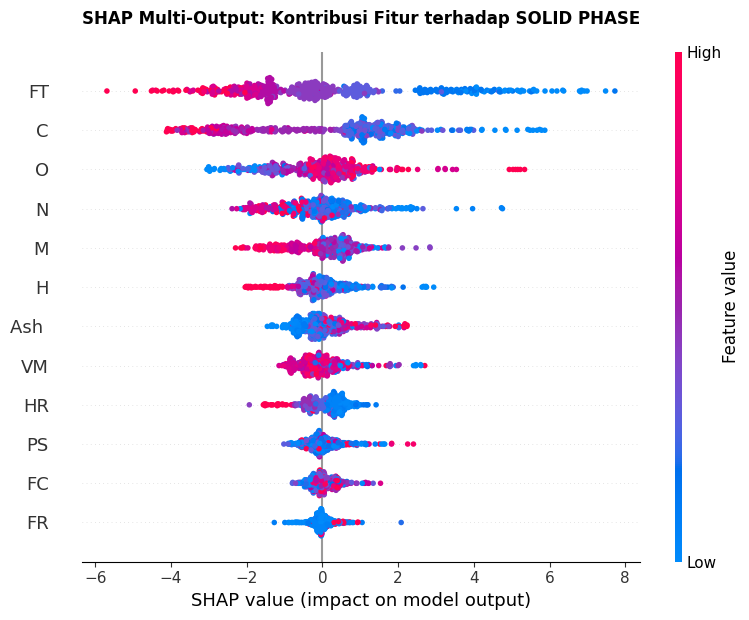

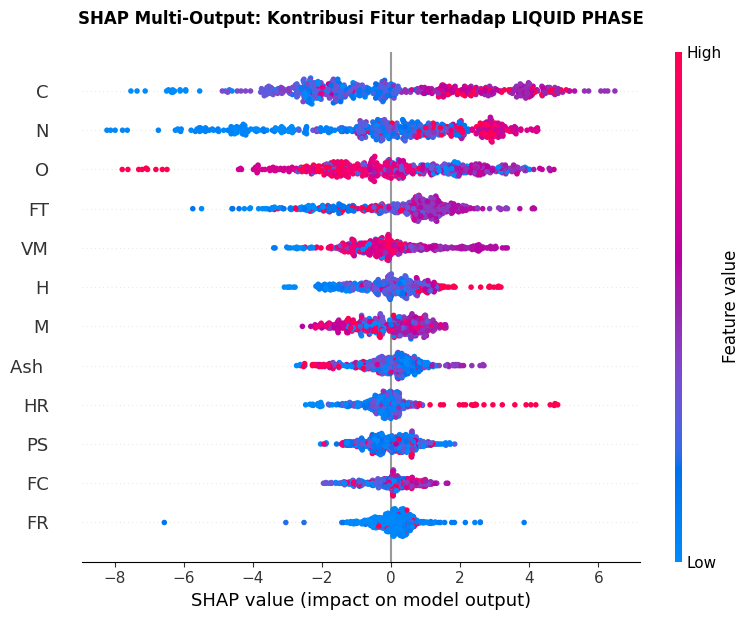

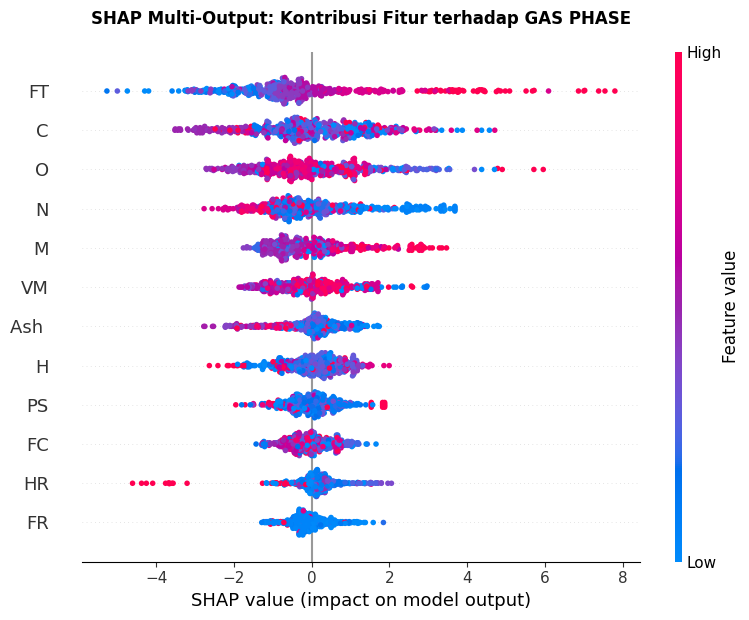

✔ Tiga file foto SHAP Global Summary Multi-output berhasil diamankan!


In [ ]:
import matplotlib.pyplot as plt
import shap

# Perhitungan nilai SHAP untuk Multi-output didasarkan pada model jawara multi-output Anda (misal: rf_multi_model)
# Karena model multi-output menghasilkan output matriks, kita panggil indeks targetnya [0=Solid, 1=Liquid, 2=Gas]
explainer_multi = shap.TreeExplainer(model_jawara)
shap_values_multi = explainer_multi(X_train)

# --- PLOT A: SOLID SUMMARY ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_multi[:, :, 0], X_train, show=False)
plt.title("SHAP Multi-Output: Kontribusi Fitur terhadap SOLID PHASE", fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_multi_solid_summary.png', dpi=300)
plt.show()

# --- PLOT B: LIQUID SUMMARY ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_multi[:, :, 1], X_train, show=False)
plt.title("SHAP Multi-Output: Kontribusi Fitur terhadap LIQUID PHASE", fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_multi_liquid_summary.png', dpi=300)
plt.show()

# --- PLOT C: GAS SUMMARY ---
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_multi[:, :, 2], X_train, show=False)
plt.title("SHAP Multi-Output: Kontribusi Fitur terhadap GAS PHASE", fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_multi_gas_summary.png', dpi=300)
plt.show()

print("✔ Tiga file foto SHAP Global Summary Multi-output berhasil diamankan!")

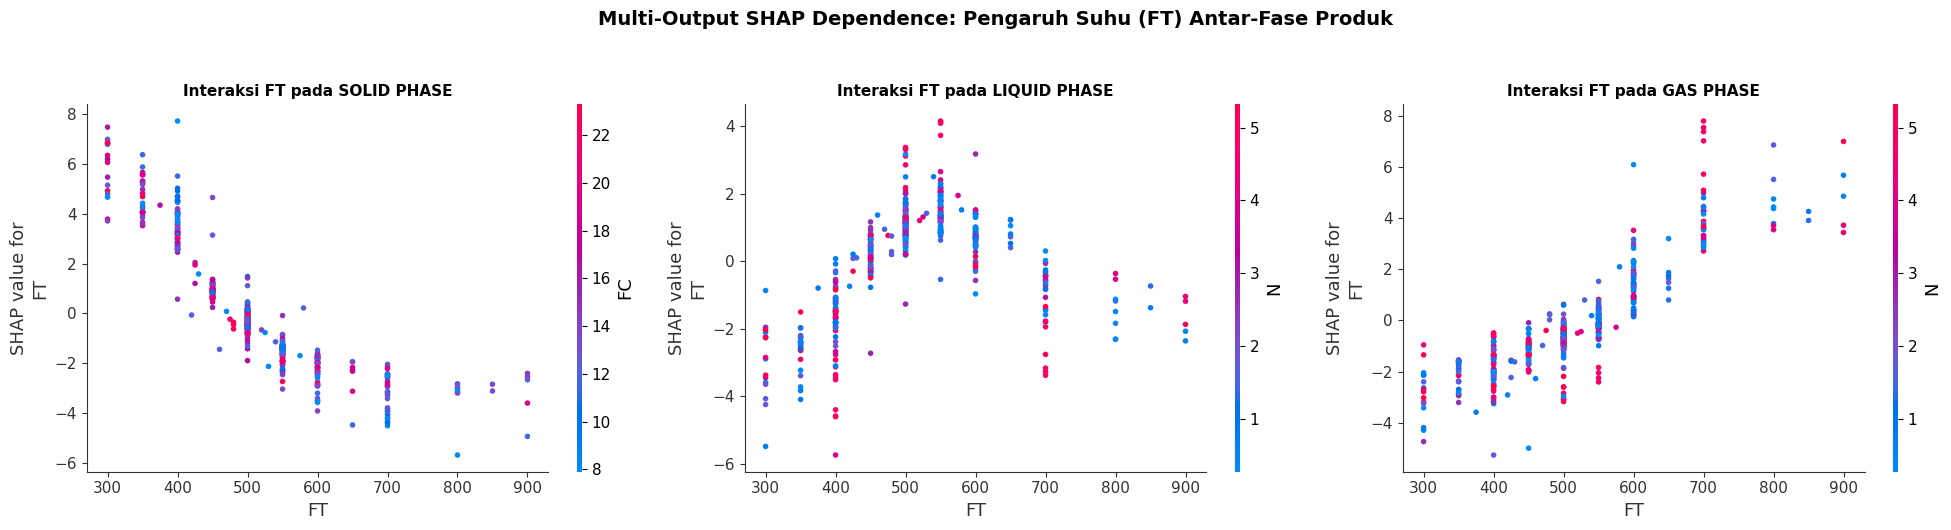

✔ Grafik 'shap_multi_combined_dependence_ft.png' sukses diekspor.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Dependence Plot Solid Multi-output
plt.sca(axes[0])
shap.dependence_plot("FT", shap_values_multi[:, :, 0].values, X_train, show=False, ax=axes[0])
axes[0].set_title("Interaksi FT pada SOLID PHASE", fontsize=11, fontweight='bold')

# Dependence Plot Liquid Multi-output
plt.sca(axes[1])
shap.dependence_plot("FT", shap_values_multi[:, :, 1].values, X_train, show=False, ax=axes[1])
axes[1].set_title("Interaksi FT pada LIQUID PHASE", fontsize=11, fontweight='bold')

# Dependence Plot Gas Multi-output
plt.sca(axes[2])
shap.dependence_plot("FT", shap_values_multi[:, :, 2].values, X_train, show=False, ax=axes[2])
axes[2].set_title("Interaksi FT pada GAS PHASE", fontsize=11, fontweight='bold')

plt.suptitle("Multi-Output SHAP Dependence: Pengaruh Suhu (FT) Antar-Fase Produk", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('shap_multi_combined_dependence_ft.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Grafik 'shap_multi_combined_dependence_ft.png' sukses diekspor.")

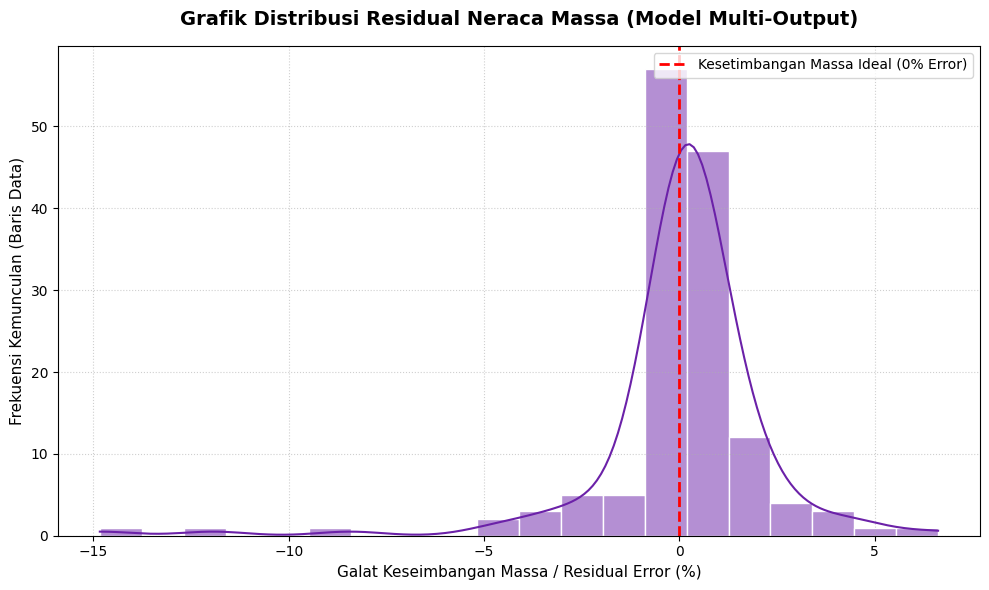

   STATISTIK ERROR NERACA MASSA MODEL MULTI-OUTPUT     
▪ Mean Mass Balance Error    : 0.0487 %
▪ Std Dev Mass Balance Error : 2.3089 %
▪ Maximum Absolute Error     : 14.8377 %


In [ ]:
# Hitung galat residu kesetimbangan massa terhadap data lab asli
total_yield_asli_test = y_test_multi['Solid phase'] + y_test_multi['Liquid phase'] + y_test_multi['Gas phase']
mass_balance_error_multi = total_yield_asli_test - total_prediksi_multi

plt.figure(figsize=(10, 6))
sns.histplot(mass_balance_error_multi, kde=True, color='#6b21a8', bins=20, edgecolor='white')
plt.axvline(0.0, color='red', linestyle='--', linewidth=2, label='Kesetimbangan Massa Ideal (0% Error)')

plt.title('Grafik Distribusi Residual Neraca Massa (Model Multi-Output)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Galat Keseimbangan Massa / Residual Error (%)', fontsize=11)
plt.ylabel('Frekuensi Kemunculan (Baris Data)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Hitung Parameter Statistika Deskriptif untuk Disidangkan
mean_mbe_m = np.mean(mass_balance_error_multi)
std_mbe_m = np.std(mass_balance_error_multi)
max_mbe_m = np.max(np.abs(mass_balance_error_multi))

print("==========================================================")
print("   STATISTIK ERROR NERACA MASSA MODEL MULTI-OUTPUT     ")
print("==========================================================")
print(f"▪ Mean Mass Balance Error    : {mean_mbe_m:.4f} %")
print(f"▪ Std Dev Mass Balance Error : {std_mbe_m:.4f} %")
print(f"▪ Maximum Absolute Error     : {max_mbe_m:.4f} %")
print("==========================================================")

#PEARSON CORRELATION

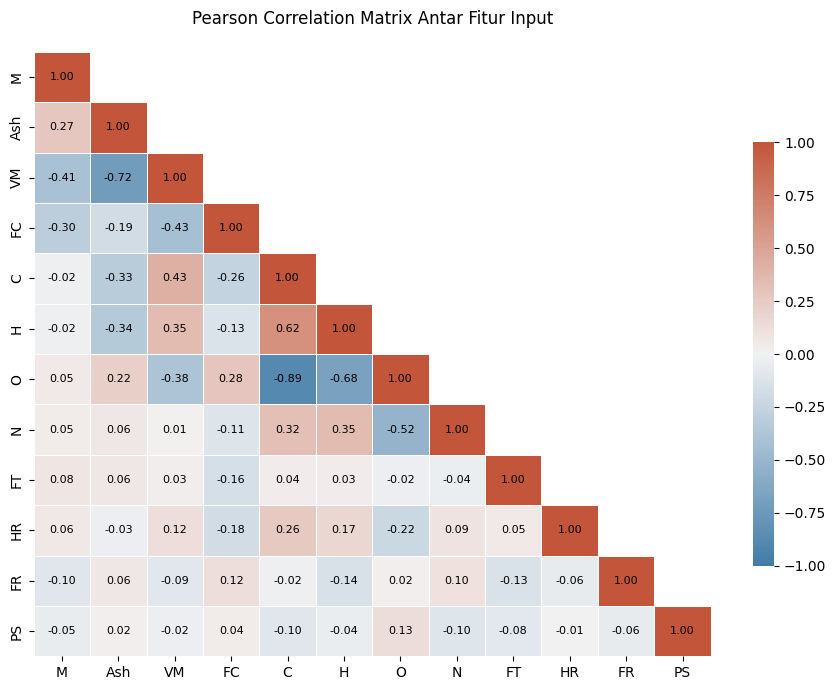

✔ Grafik 'pearson_correlation_features.png' sukses diekspor!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================================
# 1. LOAD DATASET & ISOLASI FITUR INPUT
# ====================================================================
df_train = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_train.csv', index_col='Index')

# Daftarkan target yield dan kolom non-numerik untuk dikeluarkan dari matriks
kolom_target = ['Solid phase', 'Liquid phase', 'Gas phase']
kolom_dibuang = ['Biomass species', 'index', 'Unnamed: 0'] + kolom_target

# Pastikan fitur input bersih dan berurutan sesuai gambar (M, Ash, VM, FC, dst.)
X_features = df_train.drop(columns=kolom_dibuang, errors='ignore')

# Tambahkan spasi pada 'Ash' jika nama kolom di dataset Anda menggunakan spasi ('Ash ')
# Anda bisa menyesuaikan urutan kolom di bawah ini agar 100% presisi dengan grafik Anda
urutan_kolom = ['M', 'Ash', 'VM', 'FC', 'C', 'H', 'O', 'N', 'FT', 'HR', 'FR', 'PS']
# Ganti nama jika ada ketidakcocokan spasi fisis di kolom dataset Anda
X_features.columns = X_features.columns.str.strip()
X_features = X_features[urutan_kolom]

# ====================================================================
# 2. HITUNG MATRIKS KORELASI PEARSON & BUAT MASKING SEGITIGA ATAS
# ====================================================================
corr_matrix = X_features.corr(method='pearson')

# Membuat mask untuk menyembunyikan bagian segitiga atas (di atas diagonal utama)
# k=0 artinya diagonal utama tetap terlihat, ganti k=-1 jika ingin menyembunyikannya
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# ====================================================================
# 3. KUSTOMISASI VISUALISASI HEATMAP (SANGAT MIRIP GAMBAR)
# ====================================================================
plt.figure(figsize=(9, 7))

# Menggunakan peta warna 'RdBu_r' atau 'diverging_palette' untuk warna biru-oranye-abu yang lembut
cmap = sns.diverging_palette(240, 20, as_cmap=True)

# Gambar Heatmap dengan parameter kontrol mikro
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='white', # Garis batas kotak putih tipis
    cbar_kws={"shrink": 0.7, "ticks": [-1.0, -0.75, -0.50, -0.25, 0.00, 0.25, 0.50, 0.75, 1.00]},
    annot_kws={"size": 8, "color": "black"} # Ukuran teks angka korelasi
)

# Pengaturan Judul dan Label Sumbu grafik
plt.title('Pearson Correlation Matrix Antar Fitur Input', fontsize=12, pad=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Simpan ke Google Drive / Ruang Kerja Colab dengan resolusi tajam
plt.tight_layout()
plt.savefig('pearson_correlation_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Grafik 'pearson_correlation_features.png' sukses diekspor!")

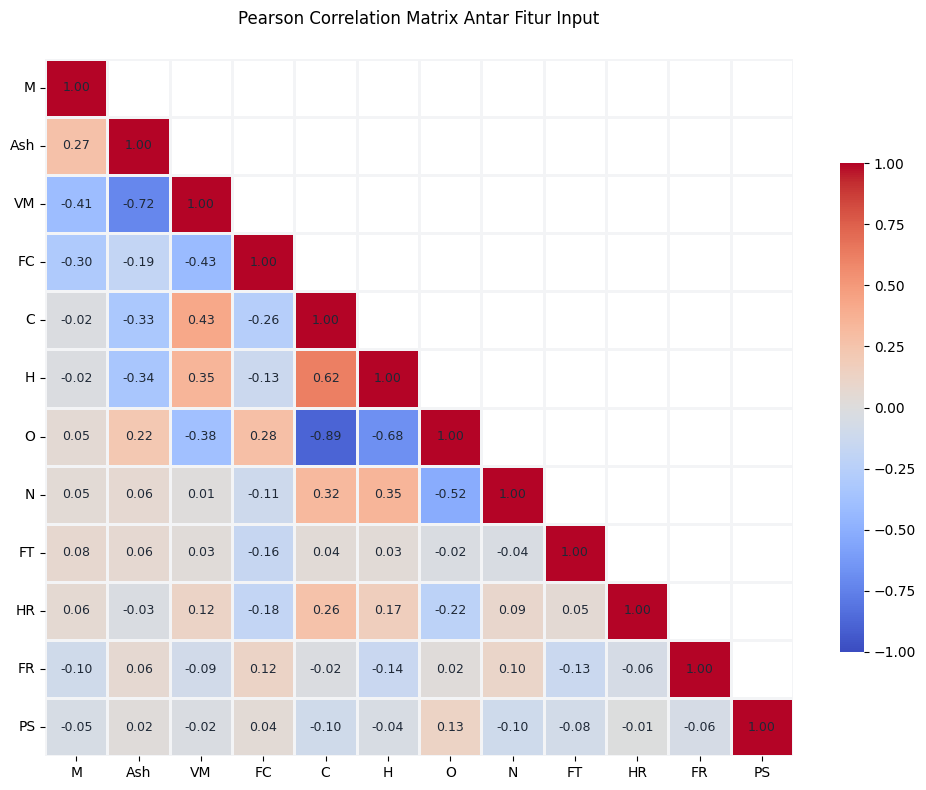

✔ Grafis korelasi dengan palet warna eksak berhasil diperbarui dan disimpan!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================================
# 1. LOAD DATASET & ISOLASI FITUR INPUT
# ====================================================================
df_train = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_train.csv', index_col='Index')

# Bersihkan nama kolom dari spasi pembantu di ujung teks
df_train.columns = df_train.columns.str.strip()

# Urutan kolom disesuaikan mutlak dengan sumbu gambar Anda
urutan_kolom = ['M', 'Ash', 'VM', 'FC', 'C', 'H', 'O', 'N', 'FT', 'HR', 'FR', 'PS']
X_features = df_train[urutan_kolom]

# ====================================================================
# 2. HITUNG MATRIKS PEARSON & REKAYASA MASKING SEGITIGA ATAS
# ====================================================================
corr_matrix = X_features.corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# ====================================================================
# 3. KUSTOMISASI WARNA ("COOLWARM") AGAR SAMA PERSIS DENGAN GAMBAR
# ====================================================================
plt.figure(figsize=(10, 8))

# Menggunakan 'coolwarm' untuk mengunci kemiripan warna oranye dan abu-biru
cmap = 'coolwarm'

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.75,       # Ketebalan garis putih antar kotak
    linecolor='#f3f4f6',   # Warna garis batas abu-putih lembut agar kotak terlihat rapi
    cbar_kws={
        "shrink": 0.7,
        "ticks": [-1.00, -0.75, -0.50, -0.25, 0.00, 0.25, 0.50, 0.75, 1.00]
    },
    annot_kws={"size": 9, "color": "#1f2937", "fontweight": "normal"} # Warna & ukuran angka dalam kotak
)

# Pengaturan teks judul dan rotasi sumbu agar presisi
plt.title('Pearson Correlation Matrix Antar Fitur Input', fontsize=12, pad=25, fontweight='normal')
plt.xticks(fontsize=10, rotation=0) # Sumbu X horizontal
plt.yticks(fontsize=10, rotation=0) # Sumbu Y horizontal

# Menghilangkan garis tepi luar plot agar terlihat clean
sns.despine(left=True, bottom=True)

# Ekspor grafik dengan resolusi publikasi paper ilmiah (300 DPI)
plt.tight_layout()
plt.savefig('pearson_correlation_exact_color.png', dpi=300, bbox_inches='tight')
plt.show()

print("✔ Grafis korelasi dengan palet warna eksak berhasil diperbarui dan disimpan!")

# REVISI STREAMLIT

In [ ]:
import pandas as pd
df_train = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_train.csv', index_col='Index')
df_test = pd.read_csv('/content/drive/MyDrive/SEM 6/02. AI TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_test.csv', index_col='Index')

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 572 entries, 1 to 751
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Biomass species  572 non-null    object 
 1   M                572 non-null    float64
 2   Ash              572 non-null    float64
 3   VM               572 non-null    float64
 4   FC               572 non-null    float64
 5   C                572 non-null    float64
 6   H                572 non-null    float64
 7   O                572 non-null    float64
 8   N                572 non-null    float64
 9   FT               572 non-null    int64  
 10  HR               572 non-null    float64
 11  FR               572 non-null    float64
 12  PS               572 non-null    float64
 13  Solid phase      572 non-null    float64
 14  Liquid phase     572 non-null    float64
 15  Gas phase        572 non-null    float64
dtypes: float64(14), int64(1), object(1)
memory usage: 76.0+ KB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143 entries, 3 to 750
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Biomass species  143 non-null    object 
 1   M                143 non-null    float64
 2   Ash              143 non-null    float64
 3   VM               143 non-null    float64
 4   FC               143 non-null    float64
 5   C                143 non-null    float64
 6   H                143 non-null    float64
 7   O                143 non-null    float64
 8   N                143 non-null    float64
 9   FT               143 non-null    int64  
 10  HR               143 non-null    float64
 11  FR               143 non-null    float64
 12  PS               143 non-null    float64
 13  Solid phase      143 non-null    float64
 14  Liquid phase     143 non-null    float64
 15  Gas phase        143 non-null    float64
dtypes: float64(14), int64(1), object(1)
memory usage: 19.0+ KB


In [ ]:
import joblib
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from xgboost import XGBRegressor


# ====================================================================
# 1. DEFINISI CUSTOM WRAPPER PIPELINE REAKTOR VIRTUAL
# ====================================================================
class PyrolysisReactorPipeline(BaseEstimator, RegressorMixin):

  def __init__(self, solid_model=None, liquid_model=None):
    self.solid_model = solid_model
    self.liquid_model = liquid_model
    self.feature_names_in_ = None

  def fit(self, X, y_solid, y_liquid):
    if hasattr(X, "columns"):
      self.feature_names_in_ = list(X.columns)

    self.solid_model.fit(X, y_solid)
    self.liquid_model.fit(X, y_liquid)
    return self

  def predict(self, X):
    # Pastikan input berupa DataFrame dengan kolom yang sesuai
    if isinstance(X, np.ndarray) and self.feature_names_in_ is not None:
      X = pd.DataFrame(X, columns=self.feature_names_in_)

    pred_solid = self.solid_model.predict(X)
    pred_liquid = self.liquid_model.predict(X)

    # Hukum Neraca Massa: Total = 100%
    pred_gas = np.maximum(0.0, 100.00 - (pred_solid + pred_liquid))

    return {
        "solid": pred_solid,
        "liquid": pred_liquid,
        "gas": pred_gas,
        "summary_df": pd.DataFrame({
            "Solid (%)": pred_solid,
            "Liquid (%)": pred_liquid,
            "Gas (%)": pred_gas,
        }),
    }


# ====================================================================
# 2. LOAD DATA
# ====================================================================
df_train = pd.read_csv(
    "/content/drive/MyDrive/SEM 6/02. AI"
    " TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_train.csv",
    index_col="Index",
)
df_test = pd.read_csv(
    "/content/drive/MyDrive/SEM 6/02. AI"
    " TERAPAN/dataset_pyrolysis/cleaning/cleaning_revisi/df_test.csv",
    index_col="Index",
)

kolom_target = ["Solid phase", "Liquid phase", "Gas phase"]
kolom_dibuang = ["Biomass species", "index", "Unnamed: 0"] + kolom_target

X_train = df_train.drop(columns=kolom_dibuang, errors="ignore")
X_test = df_test.drop(columns=kolom_dibuang, errors="ignore")

y_solid_train = df_train["Solid phase"]
y_liquid_train = df_train["Liquid phase"]

y_solid_test = df_test["Solid phase"]
y_liquid_test = df_test["Liquid phase"]
y_gas_test_asli = df_test["Gas phase"]

# ====================================================================
# 3. HYPERPARAMETER TUNING
# ====================================================================
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_xgb = {
    "n_estimators": [200, 300],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.07],
    "subsample": [0.8, 0.9],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [1, 1.5],
}

param_grid_rf = {
    "n_estimators": [200, 300],
    "max_depth": [15, 20, None],
    "min_samples_split": [2, 4],
    "max_features": ["sqrt", None],
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid_xgb,
    cv=kfold,
    scoring="r2",
    n_jobs=-1,
)
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=kfold,
    scoring="r2",
    n_jobs=-1,
)

grid_xgb.fit(X_train, y_solid_train)
grid_rf.fit(X_train, y_liquid_train)

# ====================================================================
# 4. INSTANSIASI & BUNGKUS DALAM PIPELINE REAKTOR
# ====================================================================
reactor_pipeline = PyrolysisReactorPipeline(
    solid_model=grid_xgb.best_estimator_, liquid_model=grid_rf.best_estimator_
)
reactor_pipeline.feature_names_in_ = list(X_train.columns)

# ====================================================================
# 5. EVALUASI TEST SET MENGGUNAKAN PIPELINE
# ====================================================================
predictions = reactor_pipeline.predict(X_test)
test_pred_s = predictions["solid"]
test_pred_l = predictions["liquid"]
test_pred_g = predictions["gas"]


def calculate_mape(y_true, y_pred):
  y_t, y_p = np.array(y_true), np.array(y_pred)
  mask = y_t != 0
  return np.mean(np.abs((y_t[mask] - y_p[mask]) / y_t[mask])) * 100


print("======================================================================")
print("       LAPORAN PERFORMA PIPELINE REAKTOR VIRTUAL (DATA TEST)          ")
print("======================================================================")
print(
    f"🚀 SOLID (XGBoost) ──► R²: {r2_score(y_solid_test, test_pred_s):.4f} |"
    f" MAE: {mean_absolute_error(y_solid_test, test_pred_s):.4f}%"
)
print(
    f"🚀 LIQUID (RF)     ──► R²: {r2_score(y_liquid_test, test_pred_l):.4f} |"
    f" MAE: {mean_absolute_error(y_liquid_test, test_pred_l):.4f}%"
)
print(
    f"🔬 GAS (By Diff)   ──► R²: {r2_score(y_gas_test_asli, test_pred_g):.4f} |"
    f" MAE: {mean_absolute_error(y_gas_test_asli, test_pred_g):.4f}%"
)
print("======================================================================")

# ====================================================================
# 6. SIMPAN PIPELINE UTUH
# ====================================================================
joblib.dump(reactor_pipeline, "pyrolysis_pipeline.joblib")
print("✅ Pipeline Reaktor Virtual berhasil diekspor ke: pyrolysis_pipeline.joblib")

       LAPORAN PERFORMA PIPELINE REAKTOR VIRTUAL (DATA TEST)          
🚀 SOLID (XGBoost) ──► R²: 0.7705 | MAE: 2.4638%
🚀 LIQUID (RF)     ──► R²: 0.9107 | MAE: 2.2423%
🔬 GAS (By Diff)   ──► R²: 0.2473 | MAE: 4.8487%
✅ Pipeline Reaktor Virtual berhasil diekspor ke: pyrolysis_pipeline.joblib


In [ ]:
from google.colab import files

files.download("pyrolysis_pipeline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>